# 21 — Firewall-Objective Optimization (Corrected, Thesis-Safe)

This notebook implements a corrected optimization and evaluation workflow for the AI VPN firewall.

Core design:
- train on flow-level rows
- evaluate and optimize at session level (`capture_id`)
- use isotonic as the primary calibration mode
- keep `q_min_packets_ok == 1`
- optimize firewall behavior, not generic AUC only
- use domain-aware scoring across VNAT and ISCX
- keep baseline and tuned prediction sources strictly separate

In [1]:
%matplotlib inline

import json
import math
import hashlib
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import xgboost as xgb

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.model_selection import GroupShuffleSplit

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.data_preparation import load_and_prepare_data
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.features.extract import feature_config_hash_text

from src.models.train_balanced_bagging_ensemble import run_balanced_bagging

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
output_dir = paths.artifacts_dir / "balanced_bagging_firewall_tuned"
output_dir.mkdir(parents=True, exist_ok=True)

logger.info(f"Repo root: {paths.repo_root}")
logger.info(f"Output dir: {output_dir}")

2026-03-30 11:54:14 | INFO | ai-vpn-firewall | Repo root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
2026-03-30 11:54:14 | INFO | ai-vpn-firewall | Output dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned
2026-03-30 12:05:02 | INFO | ai-vpn-firewall | Repo root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
2026-03-30 12:05:02 | INFO | ai-vpn-firewall | Output dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned


We reuse the project data-preparation entry point and fit the feature pipeline on TRAIN only.
That keeps the workflow aligned with the existing codebase and avoids leakage.

In [2]:
logger.info("Loading prepared dataframe...")
df_all = load_and_prepare_data()

required_cols = {"label", "split", "capture_id", "dataset", "flow_id"}
missing = required_cols - set(df_all.columns)
if missing:
    raise ValueError(f"Missing required columns in df_all: {sorted(missing)}")

logger.info(f"Loaded df_all shape: {df_all.shape}")
print(df_all["split"].value_counts())
print(pd.crosstab(df_all["split"], df_all["dataset"]))

logger.info("Fitting FeaturePipeline on TRAIN only...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"].copy())
feature_cols = pipeline.model_feature_names()

feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

logger.info(f"Pipeline fitted. Model features: {len(feature_cols)}")

logger.info("Transforming full dataframe...")
df_transformed = pipeline.transform(df_all.copy())

meta_cols = ["label", "split", "capture_id", "dataset", "flow_id"]
for c in meta_cols:
    df_transformed[c] = df_all[c].values

train_df = df_transformed[df_transformed["split"] == "train"].copy()
val_df   = df_transformed[df_transformed["split"] == "val"].copy()
test_df  = df_transformed[df_transformed["split"] == "test"].copy()

X_train = train_df[feature_cols].to_numpy()
y_train = train_df["label"].astype(int).to_numpy()

X_val = val_df[feature_cols].to_numpy()
y_val = val_df["label"].astype(int).to_numpy()

X_test = test_df[feature_cols].to_numpy()
y_test = test_df["label"].astype(int).to_numpy()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

2026-03-30 12:05:02 | INFO | ai-vpn-firewall | Loading prepared dataframe...
2026-03-30 12:05:02 | INFO | ai-vpn-firewall | Loading VNAT (PCAP-based)...
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | [VNAT] Loaded features.parquet (33711 flows, splits already assigned)
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | Loading ISCX (PCAP-based)...
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | [ISCX] Loaded features.parquet (76687 flows, splits already assigned)
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | Loading USBVPN (JSON-based)...
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | Removing exact duplicate flows across feature columns...
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | Ensuring numeric dtypes for feature columns...
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | ✓ All feature columns successfully converted to numeric dtypes
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | Removed 5750 duplicate flows (7.92%)
2026-03-30 12:05:03 | INFO | ai-vpn-firewall | Metadata columns pre

This notebook uses a fixed capture-level split inside the validation set:

- `val_cal`: used only for calibration fitting
- `val_score`: used only for session aggregation, threshold tuning, and objective scoring

This avoids the main methodological problem from the earlier notebook where validation was used for both calibration and scoring.

In [3]:
VAL_CAL_SIZE = 0.50
VAL_SPLIT_SEED = 42

def make_capture_level_split(df: pd.DataFrame, test_size: float = 0.5, seed: int = 42):
    """
    Split a dataframe by capture_id using GroupShuffleSplit.
    Returns two disjoint dataframes with no capture overlap.
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(df, groups=df["capture_id"]))
    df_a = df.iloc[idx_a].copy()
    df_b = df.iloc[idx_b].copy()

    overlap = set(df_a["capture_id"]).intersection(set(df_b["capture_id"]))
    if overlap:
        raise ValueError(f"Capture overlap found in split: {len(overlap)}")

    return df_a, df_b

val_cal_df, val_score_df = make_capture_level_split(val_df, test_size=1 - VAL_CAL_SIZE, seed=VAL_SPLIT_SEED)

print("VAL_CAL shape:", val_cal_df.shape)
print("VAL_SCORE shape:", val_score_df.shape)
print("\nVAL_CAL dataset by label:")
print(pd.crosstab(val_cal_df["dataset"], val_cal_df["label"]))
print("\nVAL_SCORE dataset by label:")
print(pd.crosstab(val_score_df["dataset"], val_score_df["label"]))

VAL_CAL shape: (3658, 15)
VAL_SCORE shape: (5203, 15)

VAL_CAL dataset by label:
label       0
dataset      
iscx      574
usbvpn   3006
vnat       78

VAL_SCORE dataset by label:
label       0    1
dataset           
iscx     1571   82
usbvpn   3312  193
vnat       45    0


These are the core thesis-safe helpers:

- session aggregation
- threshold tuning
- session firewall metrics
- firewall score
- domain-aware objective composition

In [4]:
def _trimmed_mean(x: pd.Series, trim_frac: float = 0.10) -> float:
    vals = np.sort(np.asarray(x, dtype=float))
    n = len(vals)
    if n == 0:
        return np.nan
    k = int(math.floor(trim_frac * n))
    if 2 * k >= n:
        return float(vals.mean())
    return float(vals[k:n-k].mean())

def _topk_mean(x: pd.Series, k: int) -> float:
    vals = np.sort(np.asarray(x, dtype=float))[::-1]
    if len(vals) == 0:
        return np.nan
    return float(vals[:min(k, len(vals))].mean())

def _weighted_mean(x: pd.Series, power: float = 2.0) -> float:
    vals = np.asarray(x, dtype=float)
    if len(vals) == 0:
        return np.nan
    w = np.maximum(vals, 1e-9) ** power
    return float(np.sum(vals * w) / np.sum(w))

def aggregate_sessions(
    df_flows: pd.DataFrame,
    score_col: str,
    rule: str = "mean",
    label_col: str = "label",
) -> pd.DataFrame:
    """
    Aggregate flow-level predictions into session-level predictions by capture_id and dataset.
    Supported rules:
      - mean
      - trimmed_mean
      - top3_mean
      - top5_mean
      - p90
      - p95
      - weighted_mean
    """
    needed = {"capture_id", "dataset", label_col, score_col}
    missing = needed - set(df_flows.columns)
    if missing:
        raise ValueError(f"aggregate_sessions missing columns: {sorted(missing)}")

    grouper = df_flows.groupby(["capture_id", "dataset"], dropna=False)

    if rule == "mean":
        df_sess = grouper[score_col].mean().reset_index(name="score")
    elif rule == "trimmed_mean":
        df_sess = grouper[score_col].apply(_trimmed_mean).reset_index(name="score")
    elif rule == "top3_mean":
        df_sess = grouper[score_col].apply(lambda s: _topk_mean(s, 3)).reset_index(name="score")
    elif rule == "top5_mean":
        df_sess = grouper[score_col].apply(lambda s: _topk_mean(s, 5)).reset_index(name="score")
    elif rule == "p90":
        df_sess = grouper[score_col].quantile(0.90).reset_index(name="score")
    elif rule == "p95":
        df_sess = grouper[score_col].quantile(0.95).reset_index(name="score")
    elif rule == "weighted_mean":
        df_sess = grouper[score_col].apply(_weighted_mean).reset_index(name="score")
    else:
        raise ValueError(f"Unknown aggregation rule: {rule}")

    df_label = grouper[label_col].max().reset_index(name="label")
    df_count = grouper.size().reset_index(name="n_flows")

    df_sess = df_sess.merge(df_label, on=["capture_id", "dataset"], how="left")
    df_sess = df_sess.merge(df_count, on=["capture_id", "dataset"], how="left")

    return df_sess

def _weighted_top5_mean(x: pd.Series) -> float:
    v = np.sort(np.asarray(x, dtype=float))[::-1][:5]
    if len(v) == 0:
        return np.nan
    w = np.array([0.40, 0.25, 0.15, 0.10, 0.10])[:len(v)]
    w = w / w.sum()
    return float(np.sum(v * w))


def _hybrid_p95_mean(x: pd.Series) -> float:
    v = np.asarray(x, dtype=float)
    if len(v) == 0:
        return np.nan
    return float(0.7 * np.mean(v) + 0.3 * np.percentile(v, 95))


def _hybrid_suspicious_08(x: pd.Series) -> float:
    v = np.asarray(x, dtype=float)
    if len(v) == 0:
        return np.nan
    mean_val = np.mean(v)
    p95_val = np.percentile(v, 95)
    prop = np.mean(v > 0.8)
    return float(0.4 * mean_val + 0.4 * p95_val + 0.2 * prop)


def _hybrid_suspicious_09(x: pd.Series) -> float:
    v = np.asarray(x, dtype=float)
    if len(v) == 0:
        return np.nan
    mean_val = np.mean(v)
    p95_val = np.percentile(v, 95)
    prop = np.mean(v > 0.9)
    return float(0.4 * mean_val + 0.4 * p95_val + 0.2 * prop)


def _max_mean_hybrid(x: pd.Series, alpha: float = 0.5) -> float:
    v = np.asarray(x, dtype=float)
    if len(v) == 0:
        return np.nan
    return float(alpha * np.mean(v) + (1 - alpha) * np.max(v))


def advanced_aggregate_sessions(
    df_flows: pd.DataFrame,
    score_col: str,
    rule: str,
    label_col: str = "label"
) -> pd.DataFrame:
    needed = {"capture_id", "dataset", label_col, score_col}
    missing = needed - set(df_flows.columns)
    if missing:
        raise ValueError(f"advanced_aggregate_sessions missing columns: {sorted(missing)}")

    grouper = df_flows.groupby(["capture_id", "dataset"], dropna=False)[score_col]

    if rule == "weighted_top5_mean":
        score = grouper.apply(_weighted_top5_mean)
    elif rule == "mean_p95_hybrid":
        score = grouper.apply(_hybrid_p95_mean)
    elif rule == "suspicious_count_hybrid_08":
        score = grouper.apply(_hybrid_suspicious_08)
    elif rule == "suspicious_count_hybrid_09":
        score = grouper.apply(_hybrid_suspicious_09)
    elif rule == "max_mean_hybrid":
        score = grouper.apply(_max_mean_hybrid)
    else:
        return aggregate_sessions(df_flows, score_col=score_col, rule=rule, label_col=label_col)

    df_sess = score.reset_index(name="score")

    df_label = (
        df_flows.groupby(["capture_id", "dataset"], dropna=False)[label_col]
        .max()
        .reset_index(name="label")
    )

    df_count = (
        df_flows.groupby(["capture_id", "dataset"], dropna=False)
        .size()
        .reset_index(name="n_flows")
    )

    df_sess = df_sess.merge(df_label, on=["capture_id", "dataset"], how="left")
    df_sess = df_sess.merge(df_count, on=["capture_id", "dataset"], how="left")

    return df_sess

In [5]:
def tune_firewall_thresholds(
    df_sess: pd.DataFrame,
    score_col: str = "score",
    label_col: str = "label",
    max_block_fp_sessions: int = 0,
    max_flagged_fp_sessions: int = 1,
):
    """
    Session-level threshold tuning.

    BLOCK threshold:
      highest-recall threshold subject to benign blocked sessions <= max_block_fp_sessions

    MONITOR threshold:
      highest-recall threshold subject to benign flagged sessions <= max_flagged_fp_sessions
    """
    if df_sess.empty:
        return 1.0, 1.0

    y = df_sess[label_col].astype(int).to_numpy()
    s = df_sess[score_col].astype(float).to_numpy()

    order = np.argsort(s)[::-1]
    y_sorted = y[order]
    s_sorted = s[order]

    fps = np.cumsum(1 - y_sorted)

    idx_block = np.searchsorted(fps, max_block_fp_sessions + 1, side="left") - 1
    if idx_block >= 0:
        block_thr = float(s_sorted[idx_block])
    else:
        block_thr = float(s_sorted[0] + 1e-6)

    idx_monitor = np.searchsorted(fps, max_flagged_fp_sessions + 1, side="left") - 1
    if idx_monitor >= 0:
        monitor_thr = float(s_sorted[idx_monitor])
    else:
        monitor_thr = float(s_sorted[0] + 1e-6)

    if monitor_thr > block_thr:
        monitor_thr = block_thr

    return block_thr, monitor_thr


def apply_firewall_policy(
    df_sess: pd.DataFrame,
    block_thr: float,
    monitor_thr: float,
    score_col: str = "score",
) -> pd.Series:
    s = df_sess[score_col].astype(float)
    policy = np.where(s >= block_thr, "BLOCK", np.where(s >= monitor_thr, "MONITOR", "ALLOW"))
    return pd.Series(policy, index=df_sess.index, name="policy")


def compute_firewall_metrics(
    df_sess: pd.DataFrame,
    score_col: str = "score",
    label_col: str = "label",
    block_thr: float | None = None,
    monitor_thr: float | None = None,
):
    """
    Compute session-level firewall metrics.
    """
    df = df_sess.copy()
    y = df[label_col].astype(int).to_numpy()
    s = df[score_col].astype(float).to_numpy()

    if block_thr is not None and monitor_thr is not None:
        df["policy"] = apply_firewall_policy(df, block_thr, monitor_thr, score_col=score_col)
    elif "policy" not in df.columns:
        raise ValueError("Either pass thresholds or provide a 'policy' column.")

    n_vpn = int((y == 1).sum())
    n_benign = int((y == 0).sum())

    block_mask = df["policy"] == "BLOCK"
    flagged_mask = df["policy"].isin(["BLOCK", "MONITOR"])

    blocked_vpn = int((block_mask & (df[label_col] == 1)).sum())
    blocked_benign = int((block_mask & (df[label_col] == 0)).sum())

    flagged_vpn = int((flagged_mask & (df[label_col] == 1)).sum())
    flagged_benign = int((flagged_mask & (df[label_col] == 0)).sum())

    block_recall = blocked_vpn / n_vpn if n_vpn > 0 else 0.0
    flagged_recall = flagged_vpn / n_vpn if n_vpn > 0 else 0.0
    block_fpr = blocked_benign / n_benign if n_benign > 0 else 0.0
    flagged_fpr = flagged_benign / n_benign if n_benign > 0 else 0.0

    if len(np.unique(y)) > 1:
        session_auc = roc_auc_score(y, s)
        session_pr_auc = average_precision_score(y, s)
    else:
        session_auc = np.nan
        session_pr_auc = np.nan

    return {
        "n_sessions": len(df),
        "n_vpn_sessions": n_vpn,
        "n_benign_sessions": n_benign,
        "block_recall": float(block_recall),
        "flagged_recall": float(flagged_recall),
        "block_fpr": float(block_fpr),
        "flagged_fpr": float(flagged_fpr),
        "blocked_vpn": blocked_vpn,
        "blocked_benign": blocked_benign,
        "flagged_vpn": flagged_vpn,
        "flagged_benign": flagged_benign,
        "session_auc": float(session_auc) if not np.isnan(session_auc) else np.nan,
        "session_pr_auc": float(session_pr_auc) if not np.isnan(session_pr_auc) else np.nan,
        "block_thr": float(block_thr) if block_thr is not None else np.nan,
        "monitor_thr": float(monitor_thr) if monitor_thr is not None else np.nan,
    }

In [6]:
@dataclass
class FirewallScoreConfig:
    target_flagged_fpr: float = 0.00
    huge_block_fp_penalty: float = 1000.0
    flagged_fpr_penalty: float = 200.0
    excess_flagged_fpr_penalty: float = 300.0
    block_recall_reward: float = 250.0
    flagged_recall_reward: float = 10.0
    auc_reward: float = 5.0
    pr_auc_reward: float = 5.0


def compute_firewall_score(metrics: dict, cfg: FirewallScoreConfig) -> float:
    """
    Thesis-safe score priorities:
    1. block_fpr == 0
    2. flagged_fpr as low as possible, with extra penalty above target
    3. high block_recall
    4. high flagged_recall
    5. minor reward for session_auc / session_pr_auc

    This is intentionally not a generic ML score.
    """
    block_fpr = float(metrics["block_fpr"])
    flagged_fpr = float(metrics["flagged_fpr"])
    block_recall = float(metrics["block_recall"])
    flagged_recall = float(metrics["flagged_recall"])
    session_auc = float(metrics["session_auc"]) if not np.isnan(metrics["session_auc"]) else 0.0
    session_pr_auc = float(metrics["session_pr_auc"]) if not np.isnan(metrics["session_pr_auc"]) else 0.0

    score = 0.0

    if block_fpr > 0:
        score -= cfg.huge_block_fp_penalty * (1.0 + block_fpr)

    score -= cfg.flagged_fpr_penalty * flagged_fpr

    if flagged_fpr > cfg.target_flagged_fpr:
        score -= cfg.excess_flagged_fpr_penalty * (flagged_fpr - cfg.target_flagged_fpr)

    score += cfg.block_recall_reward * block_recall
    score += cfg.flagged_recall_reward * flagged_recall
    score += cfg.auc_reward * session_auc
    score += cfg.pr_auc_reward * session_pr_auc

    return float(score)


def compute_domain_aware_objective(
    overall_metrics: dict,
    vnat_metrics: dict | None,
    iscx_metrics: dict | None,
    cfg: FirewallScoreConfig,
    mode: str = "weighted",
    overall_weight: float = 0.50,
    vnat_weight: float = 0.25,
    iscx_weight: float = 0.25,
) -> float:
    """
    Domain-aware objective options:
    - weighted: smoother and more stable
    - min: robustness-oriented worst-case score

    This notebook uses 'weighted' by default because it is less brittle than strict min(...)
    on a small number of validation sessions.
    """
    score_all = compute_firewall_score(overall_metrics, cfg)
    score_vnat = compute_firewall_score(vnat_metrics, cfg) if vnat_metrics is not None else score_all
    score_iscx = compute_firewall_score(iscx_metrics, cfg) if iscx_metrics is not None else score_all

    if mode == "weighted":
        return (
            overall_weight * score_all
            + vnat_weight * score_vnat
            + iscx_weight * score_iscx
        )
    elif mode == "min":
        return min(score_all, score_vnat, score_iscx)
    else:
        raise ValueError(f"Unknown domain objective mode: {mode}")


def balanced_rank_score(row):
    """
    Compute a ranking score for aggregation rules, prioritizing block_recall, flagged_recall, and penalizing FPRs.
    """
    return (
        2.0 * row['block_recall'] +
        1.0 * row['flagged_recall'] -
        3.0 * row['block_fpr'] -
        1.0 * row['flagged_fpr']
    )



We fit isotonic on `val_cal` only, then:
- transform `val_score`
- transform `test`
- aggregate at session level
- tune thresholds on session-level `val_score`
- evaluate on session-level `test`

In [7]:
def fit_platt_scaler(raw_scores: np.ndarray, y_true: np.ndarray) -> LogisticRegression:
    if len(np.unique(y_true)) < 2:
        return None
    lr = LogisticRegression(random_state=42, solver="lbfgs")
    lr.fit(raw_scores.reshape(-1, 1), y_true.astype(int))
    return lr

def predict_with_calibration(
    model,
    X_cal: np.ndarray,
    y_cal: np.ndarray,
    X_apply_dict: dict[str, np.ndarray],
):
    """
    Fit isotonic and Platt on calibration scores, then transform arbitrary apply splits.
    Returns raw/iso/platt dict.
    """
    p_cal_raw = model.predict_proba(X_cal)[:, 1]

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_cal_raw, y_cal.astype(int))

    platt = fit_platt_scaler(p_cal_raw, y_cal.astype(int))

    out = {}
    for name, X_apply in X_apply_dict.items():
        p_raw = model.predict_proba(X_apply)[:, 1]
        p_iso = iso.transform(p_raw)
        if platt is not None:
            p_platt = platt.predict_proba(p_raw.reshape(-1, 1))[:, 1]
        else:
            p_platt = p_iso
        out[name] = {
            "prob_raw": p_raw,
            "prob_iso": p_iso,
            "prob_platt": p_platt,
        }
    return out

This is the corrected optimization loop.

Important:
- train on TRAIN flows only
- fit isotonic on `val_cal`
- score on `val_score`
- aggregate to sessions before threshold tuning
- compute a domain-aware firewall objective

In [8]:
SCORE_CFG = FirewallScoreConfig(
    target_flagged_fpr=0.00,
    huge_block_fp_penalty=1000.0,
    flagged_fpr_penalty=200.0,
    excess_flagged_fpr_penalty=300.0,
    block_recall_reward=    250.0,           #120.0
    flagged_recall_reward=10.0, # 40.0
    auc_reward=5.0,
    pr_auc_reward=5.0,
)

def xgb_search_space(trial: optuna.Trial):
    return {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "booster": "gbtree",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": 4,
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 80.0, log=True),
    }

X_val_cal = val_cal_df[feature_cols].to_numpy()
y_val_cal = val_cal_df["label"].astype(int).to_numpy()

X_val_score = val_score_df[feature_cols].to_numpy()
y_val_score = val_score_df["label"].astype(int).to_numpy()

def optuna_objective_zero_fp(trial: optuna.Trial):
    """
    DEPLOYABLE FIREWALL OBJECTIVE

    Constraint: block_fpr MUST be 0.0000
    Objective: Maximize block_recall under constraint

    This reflects real firewall requirements where:
    - 1 false positive = blocking legitimate business traffic = UNACCEPTABLE
    - Missing some VPN traffic is acceptable as long as we catch enough
    """
    # Sample hyperparameters
    params = xgb_search_space(trial)

    # Train model
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val_score, y_val_score)],
        verbose=False,
    )

    # Get raw predictions on validation
    raw_scores = model.predict_proba(X_val_score)[:, 1]

    # Fit isotonic calibration on CAL, transform SCORE
    p_cal_raw = model.predict_proba(X_val_cal)[:, 1]
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip")
    iso.fit(p_cal_raw, y_val_cal)
    calibrated_scores = iso.transform(raw_scores)

    # Convert to Session level
    tmp = val_score_df[["capture_id", "dataset", "label"]].copy()
    tmp["score"] = calibrated_scores
    val_score_sess = advanced_aggregate_sessions(tmp, score_col="score", rule="weighted_top5_mean")

    benign_scores = val_score_sess[val_score_sess["label"] == 0]["score"].values
    vpn_scores = val_score_sess[val_score_sess["label"] == 1]["score"].values

    if len(benign_scores) == 0:
        return 0.0  # Invalid trial

    # Find MAXIMUM threshold that gives FPR = 0.0
    max_benign_score = float(benign_scores.max())
    safety_buffer = 0.001  # Small epsilon for robustness
    threshold = max_benign_score + safety_buffer

    # Clip to valid range
    threshold = min(threshold, 0.999)

    # Calculate metrics under zero-FP constraint
    y_pred_block = (val_score_sess["score"].values >= threshold).astype(int)
    y_val_sess = val_score_sess["label"].values

    block_fp = int(((y_val_sess == 0) & (y_pred_block == 1)).sum())
    block_tp = int(((y_val_sess == 1) & (y_pred_block == 1)).sum())
    block_fn = int(((y_val_sess == 1) & (y_pred_block == 0)).sum())

    # HARD CONSTRAINT: block_fp MUST be 0
    if block_fp > 0:
        # Heavily penalize any FP
        return -10000.0 * block_fp

    # Under constraint, maximize recall
    block_recall = block_tp / (block_tp + block_fn) if (block_tp + block_fn) > 0 else 0.0

    # Also track the safety buffer size (useful diagnostic)
    if len(vpn_scores) > 0:
        min_vpn_score = float(vpn_scores.min())
        buffer_size = min_vpn_score - max_benign_score
        trial.set_user_attr("safety_buffer", buffer_size)
        trial.set_user_attr("max_benign_score", max_benign_score)
        trial.set_user_attr("min_vpn_score", min_vpn_score)

    trial.set_user_attr("threshold", threshold)
    trial.set_user_attr("block_recall", block_recall)
    trial.set_user_attr("block_fp", block_fp)

    return block_recall  # Maximize recall under FPR=0 constraint

RUN_OPTUNA = True
N_TRIALS = 40

best_params_path = output_dir / "optuna_xgb_best_params.json"

if RUN_OPTUNA:
    logger.info(f"Starting Optuna XGBoost optimization ({N_TRIALS} trials)...")
    study = optuna.create_study(direction="maximize")
    study.optimize(optuna_objective_zero_fp, n_trials=N_TRIALS)

    best_params = study.best_params
    best_trial_info = {
        "best_value": study.best_value,
        "best_params": best_params,
        "threshold": study.best_trial.user_attrs.get("threshold"),
        "safety_buffer": study.best_trial.user_attrs.get("safety_buffer"),
        "block_fp": study.best_trial.user_attrs.get("block_fp"),
    }
    best_params_path.write_text(json.dumps(best_trial_info, indent=2), encoding="utf-8")
else:
    if not best_params_path.exists():
        raise FileNotFoundError(f"Missing saved best params: {best_params_path}")
    best_trial_info = json.loads(best_params_path.read_text(encoding="utf-8"))
    best_params = best_trial_info["best_params"]

print(json.dumps(best_trial_info, indent=2))

2026-03-30 12:05:04 | INFO | ai-vpn-firewall | Starting Optuna XGBoost optimization (40 trials)...


[I 2026-03-30 12:05:04,531] A new study created in memory with name: no-name-3e85c81c-6268-40c4-8b95-5806684308b0
[I 2026-03-30 12:05:10,796] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 350, 'learning_rate': 0.10597092013919948, 'max_depth': 4, 'subsample': 0.9010446859591712, 'colsample_bytree': 0.9052734979155893, 'min_child_weight': 10, 'reg_alpha': 1.479518606995633, 'reg_lambda': 1.5929591193439518, 'scale_pos_weight': 65.00441057367287}. Best is trial 0 with value: 0.0.
[I 2026-03-30 12:05:16,841] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 280, 'learning_rate': 0.010035827412720076, 'max_depth': 7, 'subsample': 0.8295482283933873, 'colsample_bytree': 0.6836931587638445, 'min_child_weight': 10, 'reg_alpha': 1.7163435744278488, 'reg_lambda': 0.9705296496750537, 'scale_pos_weight': 1.148339414102018}. Best is trial 0 with value: 0.0.
[I 2026-03-30 12:05:21,720] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 407, 'learni

{
  "best_value": 0.0,
  "best_params": {
    "n_estimators": 350,
    "learning_rate": 0.10597092013919948,
    "max_depth": 4,
    "subsample": 0.9010446859591712,
    "colsample_bytree": 0.9052734979155893,
    "min_child_weight": 10,
    "reg_alpha": 1.479518606995633,
    "reg_lambda": 1.5929591193439518,
    "scale_pos_weight": 65.00441057367287
  },
  "threshold": 0.001,
  "safety_buffer": 0.0,
  "block_fp": 0
}


## Exploratory: single-model tuned XGBoost

This section trains the final tuned XGBoost firewall model and saves a prediction artifact in a schema similar to the rest of the project.

In [9]:
logger.info("Training final tuned XGBoost model...")
clf_tuned = xgb.XGBClassifier(**best_params, early_stopping_rounds=50)
clf_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True,
)

pred_apply = predict_with_calibration(
    model=clf_tuned,
    X_cal=X_val_cal,
    y_cal=y_val_cal,
    X_apply_dict={
        "train": X_train,
        "val": X_val,
        "test": X_test,
    },
)

def analyze_safety_buffer(
    benign_probs: np.ndarray,
    vpn_probs: np.ndarray,
    percentiles: list[float] = [95, 99, 99.9, 100]
):
    """
    Analyze the separation between benign and VPN probability distributions.

    A large safety buffer means the model has clear separation and is
    robust to distribution shift in production.
    """
    results = {
        "max_benign": float(benign_probs.max()),
        "min_vpn": float(vpn_probs.min()),
        "safety_buffer": float(vpn_probs.min() - benign_probs.max()),
    }

    print("=" * 80)
    print("SAFETY BUFFER ANALYSIS")
    print("=" * 80)
    print(f"Maximum benign probability: {results['max_benign']:.6f}")
    print(f"Minimum VPN probability: {results['min_vpn']:.6f}")
    print(f"Safety buffer: {results['safety_buffer']:.6f}")
    print()

    if results['safety_buffer'] > 0.1:
        print("✓ EXCELLENT: Large safety buffer indicates robust separation")
    elif results['safety_buffer'] > 0.01:
        print("✓ GOOD: Moderate safety buffer, acceptable for deployment")
    elif results['safety_buffer'] > 0:
        print("⚠ WARNING: Small safety buffer, may be sensitive to distribution shift")
    else:
        print("✗ FAIL: Overlapping distributions, cannot guarantee FPR=0")
    print()

    print("Benign probability percentiles:")
    for p in percentiles:
        val = np.percentile(benign_probs, p)
        print(f"  {p:5.1f}%: {val:.6f}")

    print("\nVPN probability percentiles:")
    for p in [0, 0.1, 1, 5]:
        val = np.percentile(vpn_probs, p)
        print(f"  {p:5.1f}%: {val:.6f}")

    return results

benign_mask = (y_test == 0)
vpn_mask = (y_test == 1)

buffer_results = analyze_safety_buffer(
    benign_probs=pred_apply["test"]["prob_iso"][benign_mask],
    vpn_probs=pred_apply["test"]["prob_iso"][vpn_mask]
)

def build_prediction_frame(df_meta: pd.DataFrame, pred_block: dict, split_name: str) -> pd.DataFrame:
    out = df_meta[["capture_id", "dataset", "label", "flow_id"]].copy()
    out["p_xgb_raw"] = pred_block["prob_raw"]
    out["p_lgbm_raw"] = np.nan
    out["p_cat_raw"] = np.nan
    out["prob_raw"] = pred_block["prob_raw"]
    out["prob_iso"] = pred_block["prob_iso"]
    out["prob_platt"] = pred_block["prob_platt"]
    out["prob"] = pred_block["prob_iso"]
    out["split"] = split_name
    return out

df_pred_train = build_prediction_frame(train_df, pred_apply["train"], "train")
df_pred_val   = build_prediction_frame(val_df, pred_apply["val"], "val")
df_pred_test  = build_prediction_frame(test_df, pred_apply["test"], "test")

df_preds_tuned = pd.concat([df_pred_train, df_pred_val, df_pred_test], ignore_index=True)

tuned_preds_path = output_dir / "predictions.csv"
df_preds_tuned.to_csv(tuned_preds_path, index=False)

print("Saved tuned predictions:", tuned_preds_path)
print("Tuned predictions shape:", df_preds_tuned.shape)
print(df_preds_tuned.columns.tolist())

2026-03-30 12:07:27 | INFO | ai-vpn-firewall | Training final tuned XGBoost model...
[0]	validation_0-logloss:1.67396
[1]	validation_0-logloss:1.46964
[2]	validation_0-logloss:1.34382
[3]	validation_0-logloss:1.25262
[4]	validation_0-logloss:1.19110
[5]	validation_0-logloss:1.15469
[6]	validation_0-logloss:1.11776
[7]	validation_0-logloss:1.09666
[8]	validation_0-logloss:1.07621
[9]	validation_0-logloss:1.06012
[10]	validation_0-logloss:1.03226
[11]	validation_0-logloss:1.01347
[12]	validation_0-logloss:0.99273
[13]	validation_0-logloss:0.98343
[14]	validation_0-logloss:0.96570
[15]	validation_0-logloss:0.95121
[16]	validation_0-logloss:0.94342
[17]	validation_0-logloss:0.93353
[18]	validation_0-logloss:0.92552
[19]	validation_0-logloss:0.92349
[20]	validation_0-logloss:0.91672
[21]	validation_0-logloss:0.90944
[22]	validation_0-logloss:0.90344
[23]	validation_0-logloss:0.90118
[24]	validation_0-logloss:0.89701
[25]	validation_0-logloss:0.89583
[26]	validation_0-logloss:0.89290
[27]	va

## Final: ensemble-aligned tuned firewall evaluation

This trains the tuned ensemble version so the final tuned variant F is aligned with the baseline ensemble.
We load specific `optuna_*_firewall_best_params.json` files that should be tuned for the firewall objective.

In [10]:
def load_best_params_json(path: Path, expected_name: str):
    """
    Robust loader for saved Optuna JSON files.
    Supports either:
    - {"best_params": {...}, ...}
    - {...} as a direct parameter dict
    """
    if not path.exists():
        raise FileNotFoundError(f"Missing {expected_name} params file: {path}")

    data = json.loads(path.read_text(encoding="utf-8"))

    if isinstance(data, dict) and "best_params" in data and isinstance(data["best_params"], dict):
        return data["best_params"]

    if isinstance(data, dict):
        return data

    raise ValueError(f"Unexpected JSON structure in {path}")

In [11]:
# Load tuned family params from the new firewall-objective tuning
# NOTE: You must ensure these JSON files exist (e.g. by running an updated tuning script)
xgb_params_path  = paths.artifacts_dir / "optuna_xgboost_firewall_best_params.json"
cat_params_path  = paths.artifacts_dir / "optuna_catboost_firewall_best_params.json"
lgbm_params_path = paths.artifacts_dir / "optuna_lgbm_firewall_best_params.json"

print("Checking tuned ensemble param files...")
print("XGB :", xgb_params_path, xgb_params_path.exists())
print("CAT :", cat_params_path, cat_params_path.exists())
print("LGBM:", lgbm_params_path, lgbm_params_path.exists())

xgb_params_ens  = load_best_params_json(xgb_params_path, "XGBoost") if xgb_params_path.exists() else None
cat_params_ens  = load_best_params_json(cat_params_path, "CatBoost") if cat_params_path.exists() else None
lgbm_params_ens = load_best_params_json(lgbm_params_path, "LightGBM") if lgbm_params_path.exists() else None

print("Loaded tuned ensemble params:")
print("\nXGB:", xgb_params_ens)
print("\nCAT:", cat_params_ens)
print("\nLGBM:", lgbm_params_ens)

Checking tuned ensemble param files...
XGB : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\optuna_xgboost_firewall_best_params.json True
CAT : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\optuna_catboost_firewall_best_params.json True
LGBM: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\optuna_lgbm_firewall_best_params.json True
Loaded tuned ensemble params:

XGB: {'learning_rate': 0.10245336072769405, 'max_depth': 5, 'subsample': 0.8558358475501651, 'colsample_bytree': 0.549799373078801, 'min_child_weight': 3, 'reg_alpha': 4.85457129392925, 'reg_lambda': 4.595812025408841, 'scale_pos_weight': 11.794870662644172}

CAT: {'learning_rate': 0.09881883305434065, 'depth': 4, 'l2_leaf_reg': 0.0010171818403157242, 'random_strength': 6.406560840499167, 'bagging_temperature': 0.10765183818661189, 'border_count': 123, 'scale_pos_weight': 1.2464839888911048}

LGBM: {'learning_rate': 0.14324435955754838, 'num_leaves': 2080, 'max_depth': 5, 'min_child_samples': 55, '

In [12]:
ensemble_output_dir = paths.artifacts_dir / "balanced_bagging_firewall_tuned_ensemble"
ensemble_output_dir.mkdir(parents=True, exist_ok=True)

tuned_ensemble_preds_path = ensemble_output_dir / "predictions.csv"
tuned_ensemble_metrics_path = ensemble_output_dir / "metrics.json"

if tuned_ensemble_preds_path.exists():
    print("Tuned ensemble predictions already exist. Skipping retraining.")
else:
    logger.info("Training tuned balanced bagging ensemble...")

    results_ens = run_balanced_bagging(
        df=df_transformed,
        label_col="label",
        group_col="capture_id",
        dataset_col="dataset",
        split_col="split",
        bags_per_family=3,
        majority_ratio=1.0,
        target_fprs="0.0,0.001,0.005,0.01",
        seed=42,
        output_dir=str(ensemble_output_dir),
        model_types=["xgb", "lgbm", "cat"],
        feature_cols=feature_cols,
        weight_xgb=1.0,
        weight_lgbm=1.0,
        weight_cat=1.0,
        xgb_params=xgb_params_ens,
        cat_params=cat_params_ens,
        lgbm_params=lgbm_params_ens,
    )

    print("Tuned ensemble training finished.")
    print("Artifacts saved to:", ensemble_output_dir)

if tuned_ensemble_metrics_path.exists():
    print("Found tuned ensemble metrics:", tuned_ensemble_metrics_path)
else:
    print("Warning: tuned ensemble metrics.json not found")

Tuned ensemble predictions already exist. Skipping retraining.
Found tuned ensemble metrics: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble\metrics.json


In [13]:
if not tuned_ensemble_preds_path.exists():
    raise FileNotFoundError(f"Missing tuned ensemble predictions: {tuned_ensemble_preds_path}")

df_preds_tuned_ens = pd.read_csv(tuned_ensemble_preds_path)

expected_pred_cols = {
    "capture_id", "dataset", "label", "flow_id",
    "prob_raw", "prob_iso", "prob_platt", "prob", "split"
}
missing = expected_pred_cols - set(df_preds_tuned_ens.columns)
if missing:
    raise ValueError(f"Tuned ensemble predictions missing columns: {sorted(missing)}")

print("Tuned ensemble predictions shape:", df_preds_tuned_ens.shape)
print(df_preds_tuned_ens.columns.tolist())

Tuned ensemble predictions shape: (19908, 12)
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']


This notebook keeps baseline and tuned prediction sources strictly separate.

In [14]:
baseline_preds_path = paths.artifacts_dir / "balanced_bagging" / "predictions.csv"
if not baseline_preds_path.exists():
    raise FileNotFoundError(f"Missing baseline predictions: {baseline_preds_path}")

df_preds_base = pd.read_csv(baseline_preds_path)
df_preds_tuned = pd.read_csv(tuned_preds_path)  # single XGBoost tuned artifact
df_preds_tuned_ens = pd.read_csv(tuned_ensemble_preds_path)  # tuned ensemble artifact

expected_pred_cols = {
    "capture_id", "dataset", "label", "flow_id",
    "prob_raw", "prob_iso", "prob_platt", "prob", "split"
}
for name, dfp in [
    ("baseline", df_preds_base),
    ("tuned_single_xgb", df_preds_tuned),
    ("tuned_ensemble", df_preds_tuned_ens),
]:
    missing = expected_pred_cols - set(dfp.columns)
    if missing:
        raise ValueError(f"{name} predictions missing columns: {sorted(missing)}")

print("Baseline predictions shape:", df_preds_base.shape)
print("Tuned predictions shape:", df_preds_tuned.shape)
print("Tuned ensemble predictions shape:", df_preds_tuned_ens.shape)

print("\nBaseline columns:")
print(df_preds_base.columns.tolist())

print("\nTuned columns:")
print(df_preds_tuned.columns.tolist())

print("\nTuned ensemble columns:")
print(df_preds_tuned_ens.columns.tolist())

Baseline predictions shape: (66862, 12)
Tuned predictions shape: (66862, 12)
Tuned ensemble predictions shape: (19908, 12)

Baseline columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']

Tuned columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']

Tuned ensemble columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']


We now build clean baseline/tuned evaluation helpers.
These are the functions used for:
- corrected ablation
- aggregation comparison
- per-dataset evaluation

In [15]:
def evaluate_flow_variant(
    df_val_flows: pd.DataFrame,
    df_test_flows: pd.DataFrame,
    score_col: str,
    variant_name: str,
    source: str,
):
    b_thr, m_thr = tune_firewall_thresholds(df_val_flows.rename(columns={score_col: "score"}), score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
    df_test = df_test_flows.copy().rename(columns={score_col: "score"})
    metrics = compute_firewall_metrics(df_test, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
    metrics["Variant"] = variant_name
    metrics["source"] = source
    metrics["level"] = "flow"
    metrics["prob_mode"] = score_col.replace("prob_", "")
    metrics["aggregation"] = "none"
    return metrics

def evaluate_session_variant(
    df_val_flows: pd.DataFrame,
    df_test_flows: pd.DataFrame,
    score_col: str,
    rule: str,
    variant_name: str,
    source: str,
):
    val_sess = advanced_aggregate_sessions(df_val_flows, score_col=score_col, rule=rule)
    test_sess = advanced_aggregate_sessions(df_test_flows, score_col=score_col, rule=rule)

    b_thr, m_thr = tune_firewall_thresholds(val_sess, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
    metrics = compute_firewall_metrics(test_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)

    metrics["Variant"] = variant_name
    metrics["source"] = source
    metrics["level"] = "session"
    metrics["prob_mode"] = score_col.replace("prob_", "")
    metrics["aggregation"] = rule
    return metrics

def per_dataset_metrics_from_session_df(df_sess: pd.DataFrame, block_thr: float, monitor_thr: float, label: str):
    rows = []
    for ds in sorted(df_sess["dataset"].dropna().unique()):
        sub = df_sess[df_sess["dataset"] == ds].copy()
        m = compute_firewall_metrics(sub, score_col="score", block_thr=block_thr, monitor_thr=monitor_thr)
        m["dataset"] = ds
        m["label_name"] = label
        rows.append(m)
    return pd.DataFrame(rows)

This is the clean paired ablation:

- A: Flow Raw baseline
- B: Flow Isotonic baseline
- C: Session Raw Mean baseline
- D: Session Isotonic Mean baseline
- E: Session Platt Mean baseline
- F: Session Isotonic Mean tuned

In [16]:
print("\n" + "=" * 80)
print("PHASE 1A: EXPLORATORY SINGLE-MODEL ABLATION")
print("=" * 80)

base_val = df_preds_base[df_preds_base["split"] == "val"].copy()
base_test = df_preds_base[df_preds_base["split"] == "test"].copy()

tuned_val = df_preds_tuned[df_preds_tuned["split"] == "val"].copy()
tuned_test = df_preds_tuned[df_preds_tuned["split"] == "test"].copy()

ablation_rows = []

ablation_rows.append(evaluate_flow_variant(base_val, base_test, "prob_raw", "A: Flow Raw", "baseline"))
ablation_rows.append(evaluate_flow_variant(base_val, base_test, "prob_iso", "B: Flow Isotonic", "baseline"))

# Provide both "mean" and "weighted_top5_mean" paths to give a robust historical and current view
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_raw", "mean", "C1: Session Raw Mean", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_iso", "mean", "D1: Session Isotonic Mean", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_platt", "mean", "E1: Session Platt Mean", "baseline"))
ablation_rows.append(evaluate_session_variant(tuned_val, tuned_test, "prob_iso", "mean", "F1: Session Isotonic Mean Tuned", "tuned"))

ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_raw", "weighted_top5_mean", "C2: Session Raw Weighted Top-5", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_iso", "weighted_top5_mean", "D2: Session Isotonic Weighted Top-5", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_platt", "weighted_top5_mean", "E2: Session Platt Weighted Top-5", "baseline"))
ablation_rows.append(evaluate_session_variant(tuned_val, tuned_test, "prob_iso", "weighted_top5_mean", "F2: Session Isotonic Weighted Top-5 Tuned", "tuned"))


df_ablation = pd.DataFrame(ablation_rows)

display_cols = [
    "Variant", "source", "level", "prob_mode", "aggregation",
    "session_auc", "session_pr_auc",
    "block_recall", "flagged_recall",
    "block_fpr", "flagged_fpr",
    "blocked_benign", "flagged_benign",
    "block_thr", "monitor_thr",
]
print("\nFINAL ABLATION SUMMARY TABLE")
print(df_ablation[display_cols].to_string(index=False, float_format="%.4f"))

ref = df_ablation[df_ablation["Variant"] == "A: Flow Raw"].iloc[0]
df_delta = df_ablation.copy()
df_delta["delta_block_recall"] = df_delta["block_recall"] - ref["block_recall"]
df_delta["delta_flagged_recall"] = df_delta["flagged_recall"] - ref["flagged_recall"]
df_delta["delta_block_fpr"] = df_delta["block_fpr"] - ref["block_fpr"]
df_delta["delta_flagged_fpr"] = df_delta["flagged_fpr"] - ref["flagged_fpr"]

print("\nCOMPONENT CONTRIBUTION DELTAS")
print(
    df_delta[["Variant", "delta_block_recall", "delta_flagged_recall", "delta_block_fpr", "delta_flagged_fpr"]]
    .to_string(index=False, float_format="%+.4f")
)

def print_pair(df: pd.DataFrame, from_name: str, to_name: str):
    a = df[df["Variant"] == from_name].iloc[0]
    b = df[df["Variant"] == to_name].iloc[0]
    print(f"\n{from_name} -> {to_name}")
    print(f"  block_recall:   {a['block_recall']:.4f} -> {b['block_recall']:.4f}   ({b['block_recall'] - a['block_recall']:+.4f})")
    print(f"  flagged_recall: {a['flagged_recall']:.4f} -> {b['flagged_recall']:.4f}   ({b['flagged_recall'] - a['flagged_recall']:+.4f})")
    print(f"  block_fpr:      {a['block_fpr']:.4f} -> {b['block_fpr']:.4f}   ({b['block_fpr'] - a['block_fpr']:+.4f})")
    print(f"  flagged_fpr:    {a['flagged_fpr']:.4f} -> {b['flagged_fpr']:.4f}   ({b['flagged_fpr'] - a['flagged_fpr']:+.4f})")

print("\nPAIRED COMPARISONS")
print_pair(df_ablation, "A: Flow Raw", "B: Flow Isotonic")
print_pair(df_ablation, "C1: Session Raw Mean", "D1: Session Isotonic Mean")
print_pair(df_ablation, "D1: Session Isotonic Mean", "E1: Session Platt Mean")
print_pair(df_ablation, "D1: Session Isotonic Mean", "F1: Session Isotonic Mean Tuned")
print_pair(df_ablation, "C2: Session Raw Weighted Top-5", "D2: Session Isotonic Weighted Top-5")
print_pair(df_ablation, "D2: Session Isotonic Weighted Top-5", "E2: Session Platt Weighted Top-5")
print_pair(df_ablation, "D2: Session Isotonic Weighted Top-5", "F2: Session Isotonic Weighted Top-5 Tuned")


PHASE 1A: EXPLORATORY SINGLE-MODEL ABLATION

FINAL ABLATION SUMMARY TABLE
                                  Variant   source   level prob_mode        aggregation  session_auc  session_pr_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  blocked_benign  flagged_benign  block_thr  monitor_thr
                              A: Flow Raw baseline    flow       raw               none       0.9876          0.8905        0.5434          0.5434     0.0003       0.0003               2               2     0.9790       0.9790
                         B: Flow Isotonic baseline    flow       iso               none       0.9846          0.8599        0.5890          0.5890     0.0008       0.0008               6               6     0.9780       0.9780
                     C1: Session Raw Mean baseline session       raw               mean       0.9366          0.5480        0.2000          0.2000     0.0099       0.0099               1               1     0.7615       0.7615
                D

## Ensemble-aligned corrected ablation

This is the fair comparison:

- D1/D2 = baseline session isotonic ensemble
- F1/F2 = tuned session isotonic ensemble

In [17]:
print("\n" + "=" * 80)
print("PHASE 1B: CORRECTED ABLATION (ENSEMBLE-ALIGNED)")
print("=" * 80)

base_val = df_preds_base[df_preds_base["split"] == "val"].copy()
base_test = df_preds_base[df_preds_base["split"] == "test"].copy()

tuned_ens_val = df_preds_tuned_ens[df_preds_tuned_ens["split"] == "val"].copy()
tuned_ens_test = df_preds_tuned_ens[df_preds_tuned_ens["split"] == "test"].copy()

ablation_rows_ens = []

ablation_rows_ens.append(evaluate_flow_variant(base_val, base_test, "prob_raw", "A: Flow Raw", "baseline"))
ablation_rows_ens.append(evaluate_flow_variant(base_val, base_test, "prob_iso", "B: Flow Isotonic", "baseline"))

# Changed ablation rows to use both mean and weighted_top5_mean paths
ablation_rows_ens.append(evaluate_session_variant(base_val, base_test, "prob_raw", "mean", "C1: Session Raw Mean", "baseline"))
ablation_rows_ens.append(evaluate_session_variant(base_val, base_test, "prob_iso", "mean", "D1: Session Isotonic Mean", "baseline"))
ablation_rows_ens.append(evaluate_session_variant(base_val, base_test, "prob_platt", "mean", "E1: Session Platt Mean", "baseline"))
ablation_rows_ens.append(
    evaluate_session_variant(
        tuned_ens_val,
        tuned_ens_test,
        "prob_iso",
        "mean",
        "F1: Session Isotonic Mean Tuned Ensemble",
        "tuned_ensemble",
    )
)

ablation_rows_ens.append(evaluate_session_variant(base_val, base_test, "prob_raw", "weighted_top5_mean", "C2: Session Raw Weighted Top-5", "baseline"))
ablation_rows_ens.append(evaluate_session_variant(base_val, base_test, "prob_iso", "weighted_top5_mean", "D2: Session Isotonic Weighted Top-5", "baseline"))
ablation_rows_ens.append(evaluate_session_variant(base_val, base_test, "prob_platt", "weighted_top5_mean", "E2: Session Platt Weighted Top-5", "baseline"))
ablation_rows_ens.append(
    evaluate_session_variant(
        tuned_ens_val,
        tuned_ens_test,
        "prob_iso",
        "weighted_top5_mean",
        "F2: Session Isotonic Weighted Top-5 Tuned Ensemble",
        "tuned_ensemble",
    )
)

df_ablation_ens = pd.DataFrame(ablation_rows_ens)

display_cols = [
    "Variant", "source", "level", "prob_mode", "aggregation",
    "session_auc", "session_pr_auc",
    "block_recall", "flagged_recall",
    "block_fpr", "flagged_fpr",
    "blocked_benign", "flagged_benign",
    "block_thr", "monitor_thr",
]

print("\nFINAL ABLATION SUMMARY TABLE (ENSEMBLE-ALIGNED)")
print(df_ablation_ens[display_cols].to_string(index=False, float_format="%.4f"))


PHASE 1B: CORRECTED ABLATION (ENSEMBLE-ALIGNED)

FINAL ABLATION SUMMARY TABLE (ENSEMBLE-ALIGNED)
                                           Variant         source   level prob_mode        aggregation  session_auc  session_pr_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  blocked_benign  flagged_benign  block_thr  monitor_thr
                                       A: Flow Raw       baseline    flow       raw               none       0.9876          0.8905        0.5434          0.5434     0.0003       0.0003               2               2     0.9790       0.9790
                                  B: Flow Isotonic       baseline    flow       iso               none       0.9846          0.8599        0.5890          0.5890     0.0008       0.0008               6               6     0.9780       0.9780
                              C1: Session Raw Mean       baseline session       raw               mean       0.9366          0.5480        0.2000          0.2000     0.0099    

In [18]:
ref = df_ablation_ens[df_ablation_ens["Variant"] == "A: Flow Raw"].iloc[0]
df_delta_ens = df_ablation_ens.copy()

df_delta_ens["delta_block_recall"] = df_delta_ens["block_recall"] - ref["block_recall"]
df_delta_ens["delta_flagged_recall"] = df_delta_ens["flagged_recall"] - ref["flagged_recall"]
df_delta_ens["delta_block_fpr"] = df_delta_ens["block_fpr"] - ref["block_fpr"]
df_delta_ens["delta_flagged_fpr"] = df_delta_ens["flagged_fpr"] - ref["flagged_fpr"]

print("\nCOMPONENT CONTRIBUTION DELTAS (ENSEMBLE-ALIGNED)")
print(
    df_delta_ens[
        ["Variant", "delta_block_recall", "delta_flagged_recall", "delta_block_fpr", "delta_flagged_fpr"]
    ].to_string(index=False, float_format="%+.4f")
)

def print_pair_from(df: pd.DataFrame, from_name: str, to_name: str):
    a = df[df["Variant"] == from_name].iloc[0]
    b = df[df["Variant"] == to_name].iloc[0]
    print(f"\n{from_name} -> {to_name}")
    print(f"  block_recall:   {a['block_recall']:.4f} -> {b['block_recall']:.4f}   ({b['block_recall'] - a['block_recall']:+.4f})")
    print(f"  flagged_recall: {a['flagged_recall']:.4f} -> {b['flagged_recall']:.4f}   ({b['flagged_recall'] - a['flagged_recall']:+.4f})")
    print(f"  block_fpr:      {a['block_fpr']:.4f} -> {b['block_fpr']:.4f}   ({b['block_fpr'] - a['block_fpr']:+.4f})")
    print(f"  flagged_fpr:    {a['flagged_fpr']:.4f} -> {b['flagged_fpr']:.4f}   ({b['flagged_fpr'] - a['flagged_fpr']:+.4f})")

print("\nPAIRED COMPARISONS (ENSEMBLE-ALIGNED)")
print_pair_from(df_ablation_ens, "A: Flow Raw", "B: Flow Isotonic")
print_pair_from(df_ablation_ens, "C1: Session Raw Mean", "D1: Session Isotonic Mean")
print_pair_from(df_ablation_ens, "D1: Session Isotonic Mean", "E1: Session Platt Mean")
print_pair_from(df_ablation_ens, "D1: Session Isotonic Mean", "F1: Session Isotonic Mean Tuned Ensemble")
print_pair_from(df_ablation_ens, "C2: Session Raw Weighted Top-5", "D2: Session Isotonic Weighted Top-5")
print_pair_from(df_ablation_ens, "D2: Session Isotonic Weighted Top-5", "E2: Session Platt Weighted Top-5")
print_pair_from(df_ablation_ens, "D2: Session Isotonic Weighted Top-5", "F2: Session Isotonic Weighted Top-5 Tuned Ensemble")


COMPONENT CONTRIBUTION DELTAS (ENSEMBLE-ALIGNED)
                                           Variant  delta_block_recall  delta_flagged_recall  delta_block_fpr  delta_flagged_fpr
                                       A: Flow Raw             +0.0000               +0.0000          +0.0000            +0.0000
                                  B: Flow Isotonic             +0.0457               +0.0457          +0.0005            +0.0005
                              C1: Session Raw Mean             -0.3434               -0.3434          +0.0096            +0.0096
                         D1: Session Isotonic Mean             -0.3434               -0.3434          -0.0003            -0.0003
                            E1: Session Platt Mean             -0.3434               -0.3434          -0.0003            -0.0003
          F1: Session Isotonic Mean Tuned Ensemble             +0.0449               +0.0449          -0.0003            -0.0003
                    C2: Session Raw Weighted To

## Aggregation comparison — baseline isotonic ensemble vs tuned isotonic ensemble

In [19]:
print("\n" + "=" * 80)
print("PHASE 2B: AGGREGATION-RULE COMPARISON (BASELINE vs TUNED ENSEMBLE)")
print("=" * 80)

agg_rules = ["mean", "trimmed_mean", "top3_mean", "top5_mean", "p90", "p95", "weighted_mean", "weighted_top5_mean"]

agg_rows_ens = []

for source_name, dfv, dft in [
    ("baseline_iso", base_val, base_test),
    ("tuned_ensemble_iso", tuned_ens_val, tuned_ens_test),
]:
    for rule in agg_rules:
        val_sess = advanced_aggregate_sessions(dfv, score_col="prob_iso", rule=rule)
        test_sess = advanced_aggregate_sessions(dft, score_col="prob_iso", rule=rule)
        b_thr, m_thr = tune_firewall_thresholds(val_sess, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
        m = compute_firewall_metrics(test_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
        m["source"] = source_name
        m["aggregation"] = rule
        agg_rows_ens.append(m)

df_agg_ens = pd.DataFrame(agg_rows_ens)

agg_cols = [
    "source", "aggregation",
    "session_auc", "session_pr_auc",
    "block_recall", "flagged_recall",
    "block_fpr", "flagged_fpr",
    "block_thr", "monitor_thr",
]

print(df_agg_ens[agg_cols].sort_values(["source", "aggregation"]).to_string(index=False, float_format="%.4f"))

df_agg_ens["balanced_rank_score"] = df_agg_ens.apply(balanced_rank_score, axis=1)
df_agg_ens["Variant"] = ("Agg: " + df_agg_ens["source"].astype(str) + " + " + df_agg_ens["aggregation"].astype(str))

print("\nBest aggregation per source (deployment-oriented):")
print(
    df_agg_ens.sort_values("balanced_rank_score", ascending=False)
              .groupby("source")
              .head(1)[["source", "aggregation", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "balanced_rank_score"]]
              .to_string(index=False, float_format="%.4f")
)


PHASE 2B: AGGREGATION-RULE COMPARISON (BASELINE vs TUNED ENSEMBLE)
            source        aggregation  session_auc  session_pr_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  block_thr  monitor_thr
      baseline_iso               mean       0.9267          0.4754        0.2000          0.2000     0.0000       0.0000     0.6541       0.6541
      baseline_iso                p90       0.9208          0.4000        0.6000          0.6000     0.0792       0.0792     0.3407       0.3407
      baseline_iso                p95       0.9129          0.3642        0.6000          0.6000     0.1089       0.1089     0.3407       0.3407
      baseline_iso          top3_mean       0.9089          0.3746        0.6000          0.6000     0.0990       0.0990     0.3407       0.3407
      baseline_iso          top5_mean       0.9040          0.3739        0.4000          0.4000     0.0693       0.0693     0.3407       0.3407
      baseline_iso       trimmed_mean       0.9267          0.

This is a repeated capture-level resampling analysis.

For each repeat:
- resample validation sessions
- retune thresholds
- resample test sessions
- evaluate firewall metrics

This is stronger than a single fixed-threshold report because it tests threshold stability too.

In [20]:
print("\n" + "=" * 80)
print("PHASE 3: REPEATED STABILITY ANALYSIS")
print("=" * 80)

def repeated_session_stability(
    df_val_flows: pd.DataFrame,
    df_test_flows: pd.DataFrame,
    score_col: str = "prob_iso",
    rule: str = "mean",
    n_repeats: int = 200,
    val_frac: float = 0.80,
    test_frac: float = 0.80,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)

    val_sess_all = advanced_aggregate_sessions(df_val_flows, score_col=score_col, rule=rule)
    test_sess_all = advanced_aggregate_sessions(df_test_flows, score_col=score_col, rule=rule)

    val_caps = np.array(sorted(val_sess_all["capture_id"].unique()))
    test_caps = np.array(sorted(test_sess_all["capture_id"].unique()))

    rows = []
    for i in range(n_repeats):
        n_val = max(4, int(round(len(val_caps) * val_frac)))
        n_test = max(4, int(round(len(test_caps) * test_frac)))

        val_sample_caps = rng.choice(val_caps, size=n_val, replace=False)
        test_sample_caps = rng.choice(test_caps, size=n_test, replace=False)

        val_sess = val_sess_all[val_sess_all["capture_id"].isin(val_sample_caps)].copy()
        test_sess = test_sess_all[test_sess_all["capture_id"].isin(test_sample_caps)].copy()

        if val_sess["label"].nunique() < 2 or test_sess["label"].nunique() < 2:
            continue

        b_thr, m_thr = tune_firewall_thresholds(val_sess, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
        m = compute_firewall_metrics(test_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
        m["repeat"] = i
        rows.append(m)

    return pd.DataFrame(rows)

df_stability_base = repeated_session_stability(base_val, base_test, score_col="prob_iso", rule="weighted_top5_mean", n_repeats=200, seed=42)
df_stability_tuned = repeated_session_stability(tuned_val, tuned_test, score_col="prob_iso", rule="weighted_top5_mean", n_repeats=200, seed=43)

def summarize_stability(df_rep: pd.DataFrame, label: str):
    cols = ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc"]
    desc = df_rep[cols].agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index": "metric"})
    zero_block_fpr_freq = float((df_rep["block_fpr"] == 0.0).mean()) if len(df_rep) else np.nan
    zero_flagged_fpr_freq = float((df_rep["flagged_fpr"] == 0.0).mean()) if len(df_rep) else np.nan

    print(f"\nSTABILITY SUMMARY — {label}")
    print(desc.to_string(index=False, float_format="%.4f"))
    print(f"zero block FPR frequency:   {zero_block_fpr_freq:.4f}")
    print(f"zero flagged FPR frequency: {zero_flagged_fpr_freq:.4f}")

summarize_stability(df_stability_base, "Baseline Session Isotonic Weighted Top-5")
summarize_stability(df_stability_tuned, "Tuned Session Isotonic Weighted Top-5")


PHASE 3: REPEATED STABILITY ANALYSIS

STABILITY SUMMARY — Baseline Session Isotonic Weighted Top-5
        metric   mean    std    min    max
  block_recall 0.3553 0.1583 0.0000 0.6667
flagged_recall 0.3553 0.1583 0.0000 0.6667
     block_fpr 0.0570 0.0285 0.0000 0.0875
   flagged_fpr 0.0570 0.0285 0.0000 0.0875
   session_auc 0.9030 0.0240 0.8394 0.9695
zero block FPR frequency:   0.1710
zero flagged FPR frequency: 0.1710

STABILITY SUMMARY — Tuned Session Isotonic Weighted Top-5
        metric   mean    std    min    max
  block_recall 0.8429 0.3648 0.0000 1.0000
flagged_recall 0.8429 0.3648 0.0000 1.0000
     block_fpr 0.8429 0.3648 0.0000 1.0000
   flagged_fpr 0.8429 0.3648 0.0000 1.0000
   session_auc 0.5000 0.0000 0.5000 0.5000
zero block FPR frequency:   0.1571
zero flagged FPR frequency: 0.1571


## Stability analysis — baseline ensemble vs tuned ensemble
Note: Session counts in the test set are small (especially for ISCX).
Stability analysis uses bootstrap resampling to estimate the variability of the metrics.
Results should be interpreted as robust but conditional on the available sample size.

In [21]:
print("\n" + "=" * 80)
print("PHASE 3B: STABILITY ANALYSIS (BASELINE vs TUNED ENSEMBLE)")
print("=" * 80)

df_stability_base_ens = repeated_session_stability(
    base_val, base_test, score_col="prob_iso", rule="weighted_top5_mean", n_repeats=200, seed=42
)

df_stability_tuned_ens = repeated_session_stability(
    tuned_ens_val, tuned_ens_test, score_col="prob_iso", rule="weighted_top5_mean", n_repeats=200, seed=43
)

summarize_stability(df_stability_base_ens, "Baseline Session Weighted Top5 Ensemble")
summarize_stability(df_stability_tuned_ens, "Tuned Session Weighted Top5 Ensemble")


PHASE 3B: STABILITY ANALYSIS (BASELINE vs TUNED ENSEMBLE)

STABILITY SUMMARY — Baseline Session Weighted Top5 Ensemble
        metric   mean    std    min    max
  block_recall 0.3553 0.1583 0.0000 0.6667
flagged_recall 0.3553 0.1583 0.0000 0.6667
     block_fpr 0.0570 0.0285 0.0000 0.0875
   flagged_fpr 0.0570 0.0285 0.0000 0.0875
   session_auc 0.9030 0.0240 0.8394 0.9695
zero block FPR frequency:   0.1710
zero flagged FPR frequency: 0.1710

STABILITY SUMMARY — Tuned Session Weighted Top5 Ensemble
        metric   mean    std    min    max
  block_recall 0.7185 0.0812 0.5455 1.0000
flagged_recall 0.7185 0.0812 0.5455 1.0000
     block_fpr 0.0077 0.0249 0.0000 0.1818
   flagged_fpr 0.0077 0.0249 0.0000 0.1818
   session_auc 0.9684 0.0104 0.9461 0.9915
zero block FPR frequency:   0.8750
zero flagged FPR frequency: 0.8750


This section removes top dataset-encoding features and checks whether:

- dataset-detector AUC decreases
- firewall robustness improves or degrades
- per-dataset session behavior changes

In [22]:
print("\n" + "=" * 80)
print("PHASE 4: DOMAIN-SHIFT MITIGATION VIA FEATURE PRUNING")
print("=" * 80)

# Use known domain-heavy features first, then fill from dataset-detector importance if needed.
known_domain_feats = [
    "iat_all_median",
    "h_size_all_00",
    "sz_all_p25",
    "iat_all_p75",
    "iat_all_mean",
    "iat_mean_min",
    "iat_std_max",
]

# Train a dataset detector on TRAIN only
df_train_ds = train_df.copy()
df_train_ds["target_ds"] = (df_train_ds["dataset"] == "iscx").astype(int)

X_train_ds = df_train_ds[feature_cols].to_numpy()
y_train_ds = df_train_ds["target_ds"].to_numpy()

df_test_ds = test_df.copy()
df_test_ds["target_ds"] = (df_test_ds["dataset"] == "iscx").astype(int)
X_test_ds = df_test_ds[feature_cols].to_numpy()
y_test_ds = df_test_ds["target_ds"].to_numpy()

dom_clf_full = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="auc",
    random_state=42,
    n_jobs=4,
)
dom_clf_full.fit(X_train_ds, y_train_ds, verbose=False)
p_dom_full = dom_clf_full.predict_proba(X_test_ds)[:, 1]
dataset_auc_full = roc_auc_score(y_test_ds, p_dom_full)

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": dom_clf_full.feature_importances_,
}).sort_values("importance", ascending=False)

top_detector_feats = imp_df["feature"].head(10).tolist()
print("Dataset-detector AUC (full):", f"{dataset_auc_full:.4f}")
print("\nTop dataset-detector features:")
print(imp_df.head(10).to_string(index=False))

prune_feats = []
for f in known_domain_feats + top_detector_feats:
    if f in feature_cols and f not in prune_feats:
        prune_feats.append(f)
    if len(prune_feats) == 5:
        break

print("\nPruning these 5 features:")
print(prune_feats)

feature_cols_pruned = [c for c in feature_cols if c not in prune_feats]
print(f"Full features: {len(feature_cols)} | Pruned features: {len(feature_cols_pruned)}")


PHASE 4: DOMAIN-SHIFT MITIGATION VIA FEATURE PRUNING
Dataset-detector AUC (full): 0.9999

Top dataset-detector features:
                  feature  importance
  direction_balance_bytes    0.806874
      dispersion_symmetry    0.077480
direction_balance_packets    0.052528
      sz_p75_median_ratio    0.036760
      sz_p25_median_ratio    0.012111
        sz_coef_variation    0.010970
       sz_iqr_norm_median    0.003279

Pruning these 5 features:
['direction_balance_bytes', 'dispersion_symmetry', 'direction_balance_packets', 'sz_p75_median_ratio', 'sz_p25_median_ratio']
Full features: 7 | Pruned features: 2


In [23]:
X_train_pr = train_df[feature_cols_pruned].to_numpy()
X_val_cal_pr = val_cal_df[feature_cols_pruned].to_numpy()
X_val_pr = val_df[feature_cols_pruned].to_numpy()
X_test_pr = test_df[feature_cols_pruned].to_numpy()

# Dataset detector after pruning
X_train_ds_pr = df_train_ds[feature_cols_pruned].to_numpy()
X_test_ds_pr = df_test_ds[feature_cols_pruned].to_numpy()

dom_clf_pr = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="auc",
    random_state=42,
    n_jobs=4,
)
dom_clf_pr.fit(X_train_ds_pr, y_train_ds, verbose=False)
p_dom_pr = dom_clf_pr.predict_proba(X_test_ds_pr)[:, 1]
dataset_auc_pruned = roc_auc_score(y_test_ds, p_dom_pr)

print("Dataset-detector AUC (pruned):", f"{dataset_auc_pruned:.4f}")

clf_pruned = xgb.XGBClassifier(**best_params)
clf_pruned.fit(X_train_pr, y_train, verbose=False)

pred_pr = predict_with_calibration(
    model=clf_pruned,
    X_cal=X_val_cal_pr,
    y_cal=y_val_cal,
    X_apply_dict={
        "val": X_val_pr,
        "test": X_test_pr,
    },
)

df_val_pr = val_df[["capture_id", "dataset", "label"]].copy()
df_val_pr["score"] = pred_pr["val"]["prob_iso"]

df_test_pr = test_df[["capture_id", "dataset", "label"]].copy()
df_test_pr["score"] = pred_pr["test"]["prob_iso"]

val_sess_pr = advanced_aggregate_sessions(df_val_pr, score_col="score", rule="weighted_top5_mean")
test_sess_pr = advanced_aggregate_sessions(df_test_pr, score_col="score", rule="weighted_top5_mean")

b_pr, m_pr = tune_firewall_thresholds(val_sess_pr, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
metrics_pruned = compute_firewall_metrics(test_sess_pr, score_col="score", block_thr=b_pr, monitor_thr=m_pr)

print("\nPruned-model overall session metrics:")
print(json.dumps(metrics_pruned, indent=2))

df_pruned_per_ds = per_dataset_metrics_from_session_df(test_sess_pr, b_pr, m_pr, "pruned_single_model_iso_weighted_top5")
print("\nPruned-model per-dataset metrics:")
print(
    df_pruned_per_ds[["dataset", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
    .to_string(index=False, float_format="%.4f")
)

# Compare against full tuned ENSEMBLE session isotonic weighted_top5_mean
tuned_val_sess_mean = advanced_aggregate_sessions(tuned_ens_val, score_col="prob_iso", rule="weighted_top5_mean")
tuned_test_sess_mean = advanced_aggregate_sessions(tuned_ens_test, score_col="prob_iso", rule="weighted_top5_mean")
b_full, m_full = tune_firewall_thresholds(tuned_val_sess_mean, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
metrics_full_tuned = compute_firewall_metrics(
    tuned_test_sess_mean,
    score_col="score",
    block_thr=b_full,
    monitor_thr=m_full,
)

compare_pruning = pd.DataFrame([
    {
        "model": "full_tuned_ensemble_iso_weighted_top5",
        "dataset_auc": dataset_auc_full,
        **metrics_full_tuned,
    },
    {
        "model": "pruned_single_model_iso_weighted_top5",
        "dataset_auc": dataset_auc_pruned,
        **metrics_pruned,
    },
])

print("\nFull vs pruned comparison:")
print(
    compare_pruning[["model", "dataset_auc", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
    .to_string(index=False, float_format="%.4f")
)

Dataset-detector AUC (pruned): 0.8937

Pruned-model overall session metrics:
{
  "n_sessions": 106,
  "n_vpn_sessions": 5,
  "n_benign_sessions": 101,
  "block_recall": 1.0,
  "flagged_recall": 1.0,
  "block_fpr": 1.0,
  "flagged_fpr": 1.0,
  "blocked_vpn": 5,
  "blocked_benign": 101,
  "flagged_vpn": 5,
  "flagged_benign": 101,
  "session_auc": 0.5,
  "session_pr_auc": 0.04716981132075472,
  "block_thr": 0.0,
  "monitor_thr": 0.0
}

Pruned-model per-dataset metrics:
dataset  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
   iscx        1.0000          1.0000     1.0000       1.0000       0.5000          0.1053
 usbvpn        1.0000          1.0000     1.0000       1.0000       0.5000          0.0270
   vnat        1.0000          1.0000     1.0000       1.0000       0.5000          0.0769

Full vs pruned comparison:
                                model  dataset_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
fu

This is where we check whether the strongest configuration is actually robust on VNAT and ISCX separately.

In [24]:
print("\n" + "=" * 80)
print("PHASE 5: PER-DATASET COMPARISON")
print("=" * 80)

# Baseline D
base_D_val = advanced_aggregate_sessions(base_val, score_col="prob_iso", rule="weighted_top5_mean")
base_D_test = advanced_aggregate_sessions(base_test, score_col="prob_iso", rule="weighted_top5_mean")
b_D, m_D = tune_firewall_thresholds(base_D_val, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
df_base_D_ds = per_dataset_metrics_from_session_df(base_D_test, b_D, m_D, "baseline_D_weighted_top5")

# Tuned F
tuned_F_val = advanced_aggregate_sessions(tuned_val, score_col="prob_iso", rule="weighted_top5_mean")
tuned_F_test = advanced_aggregate_sessions(tuned_ens_test, score_col="prob_iso", rule="weighted_top5_mean")
b_F, m_F = tune_firewall_thresholds(tuned_F_val, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
df_tuned_F_ds = per_dataset_metrics_from_session_df(tuned_F_test, b_F, m_F, "tuned_F_weighted_top5")

# Pruned
df_pruned_ds = df_pruned_per_ds.copy()

df_per_dataset = pd.concat([df_base_D_ds, df_tuned_F_ds, df_pruned_ds], ignore_index=True)

print(
    df_per_dataset[["label_name", "dataset", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
    .to_string(index=False, float_format="%.4f")
)


PHASE 5: PER-DATASET COMPARISON
                           label_name dataset  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
             baseline_D_weighted_top5    iscx        0.5000          0.5000     0.4118       0.4118       0.6324          0.1458
             baseline_D_weighted_top5  usbvpn        0.5000          0.5000     0.0000       0.0000       1.0000          1.0000
             baseline_D_weighted_top5    vnat        0.0000          0.0000     0.0000       0.0000       0.8333          0.3333
                tuned_F_weighted_top5    iscx        1.0000          1.0000     1.0000       1.0000       1.0000          1.0000
                tuned_F_weighted_top5    vnat        1.0000          1.0000     1.0000       1.0000       1.0000          1.0000
pruned_single_model_iso_weighted_top5    iscx        1.0000          1.0000     1.0000       1.0000       0.5000          0.1053
pruned_single_model_iso_weighted_top5  usbvpn        1.0000     

## Per-dataset comparison — baseline D vs tuned ensemble F

In [25]:
print("\n" + "=" * 80)
print("PHASE 5B: PER-DATASET COMPARISON (ENSEMBLE-ALIGNED)")
print("=" * 80)

base_D_val = advanced_aggregate_sessions(base_val, score_col="prob_iso", rule="weighted_top5_mean")
base_D_test = advanced_aggregate_sessions(base_test, score_col="prob_iso", rule="weighted_top5_mean")
b_D, m_D = tune_firewall_thresholds(base_D_val, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
df_base_D_ds_ens = per_dataset_metrics_from_session_df(base_D_test, b_D, m_D, "baseline_D_weighted_top5")

tuned_F_val = advanced_aggregate_sessions(tuned_ens_val, score_col="prob_iso", rule="weighted_top5_mean")
tuned_F_test = advanced_aggregate_sessions(tuned_ens_test, score_col="prob_iso", rule="weighted_top5_mean")
b_F, m_F = tune_firewall_thresholds(tuned_F_val, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
df_tuned_F_ds_ens = per_dataset_metrics_from_session_df(tuned_F_test, b_F, m_F, "tuned_F_ensemble_weighted_top5")

df_per_dataset_ens = pd.concat([df_base_D_ds_ens, df_tuned_F_ds_ens], ignore_index=True)

print(
    df_per_dataset_ens[
        ["label_name", "dataset", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]
    ].to_string(index=False, float_format="%.4f")
)


PHASE 5B: PER-DATASET COMPARISON (ENSEMBLE-ALIGNED)
                    label_name dataset  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
      baseline_D_weighted_top5    iscx        0.5000          0.5000     0.4118       0.4118       0.6324          0.1458
      baseline_D_weighted_top5  usbvpn        0.5000          0.5000     0.0000       0.0000       1.0000          1.0000
      baseline_D_weighted_top5    vnat        0.0000          0.0000     0.0000       0.0000       0.8333          0.3333
tuned_F_ensemble_weighted_top5    iscx        1.0000          1.0000     0.0000       0.0000       1.0000          1.0000
tuned_F_ensemble_weighted_top5    vnat        0.6154          0.6154     0.0000       0.0000       1.0000          1.0000


Clean plots:
1. block recall by variant
2. flagged recall by variant
3. block FPR by variant
4. flagged FPR by variant
5. aggregation comparison
6. stability distributions
7. per-dataset comparison
8. feature-pruning comparison

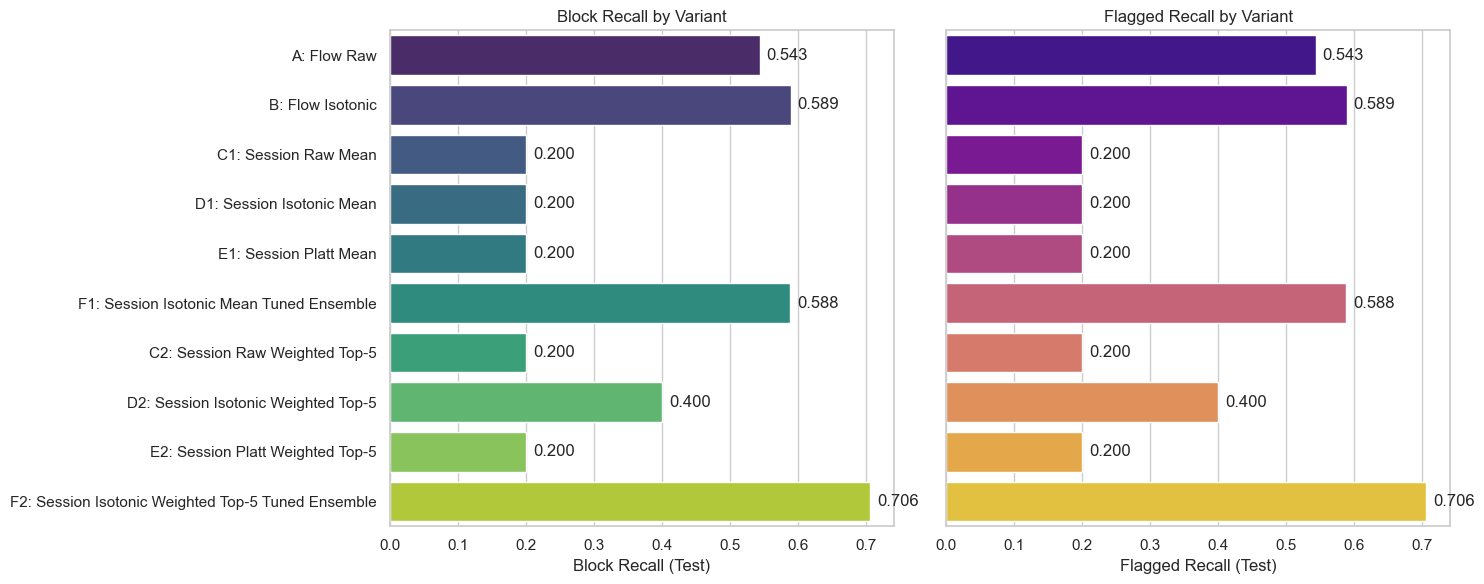

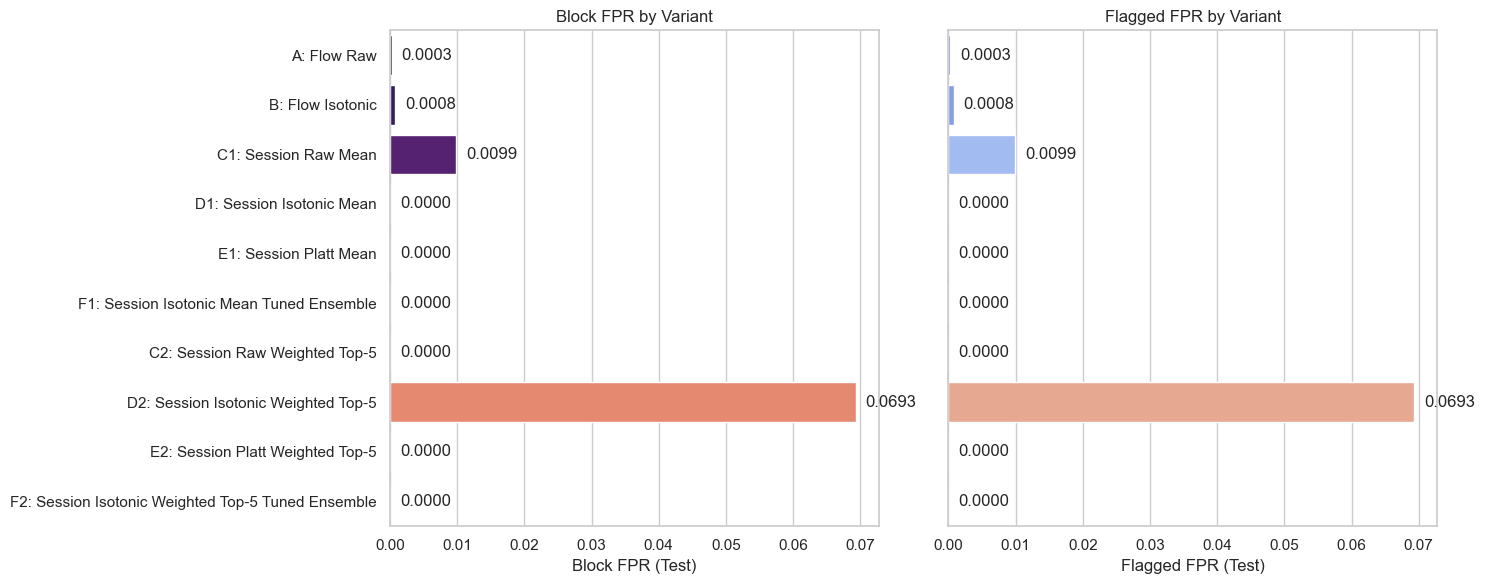

In [26]:
plot_order = df_ablation_ens["Variant"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=df_ablation_ens,
    x="block_recall",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Block Recall by Variant")
axes[0].set_xlabel("Block Recall (Test)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.3f}", (w + 0.01, p.get_y() + p.get_height() / 2), va="center")

sns.barplot(
    data=df_ablation_ens,
    x="flagged_recall",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="plasma",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Flagged Recall by Variant")
axes[1].set_xlabel("Flagged Recall (Test)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.3f}", (w + 0.01, p.get_y() + p.get_height() / 2), va="center")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=df_ablation_ens,
    x="block_fpr",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="magma",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Block FPR by Variant")
axes[0].set_xlabel("Block FPR (Test)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.4f}", (w + 0.0015, p.get_y() + p.get_height() / 2), va="center")

sns.barplot(
    data=df_ablation_ens,
    x="flagged_fpr",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="coolwarm",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Flagged FPR by Variant")
axes[1].set_xlabel("Flagged FPR (Test)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.4f}", (w + 0.0015, p.get_y() + p.get_height() / 2), va="center")

plt.tight_layout()
plt.show()

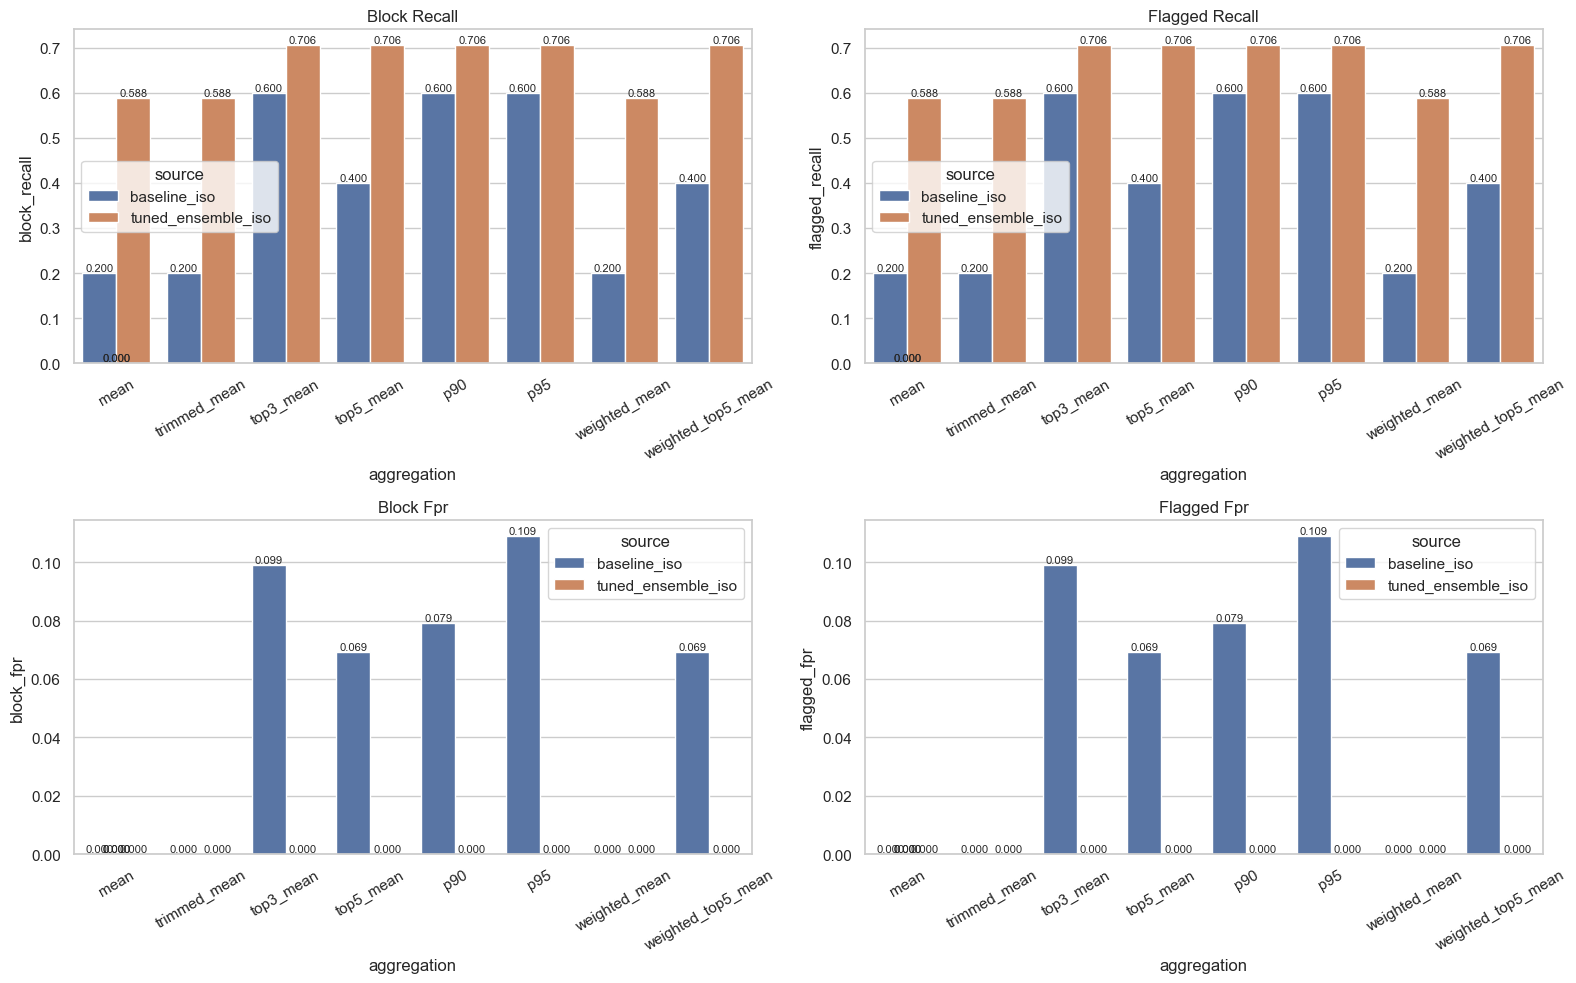

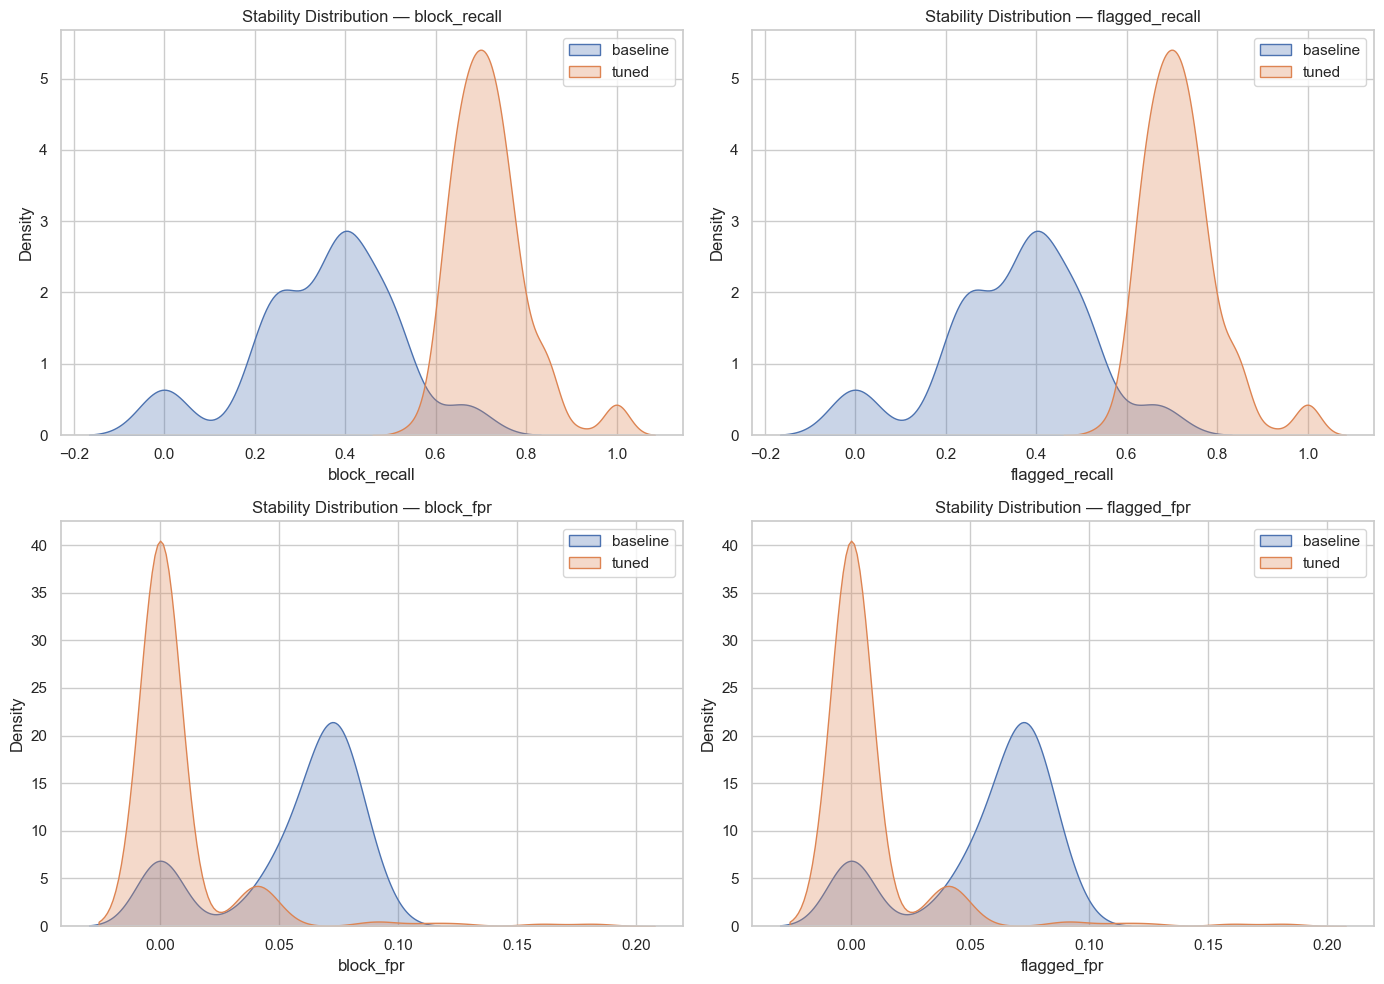

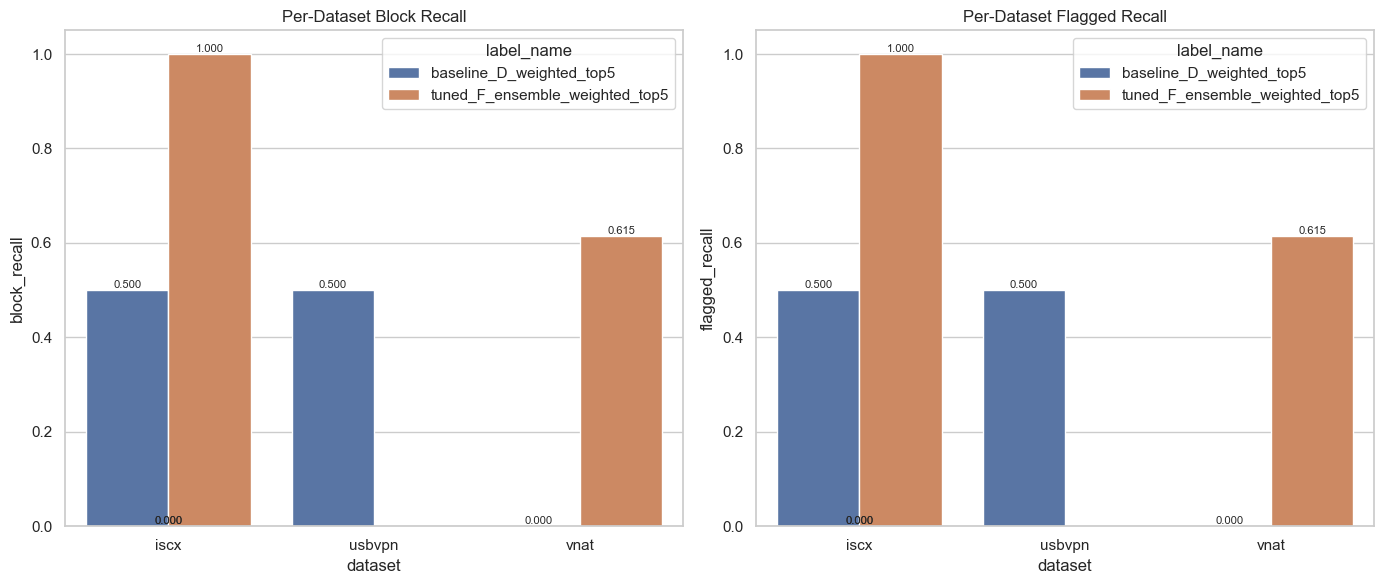

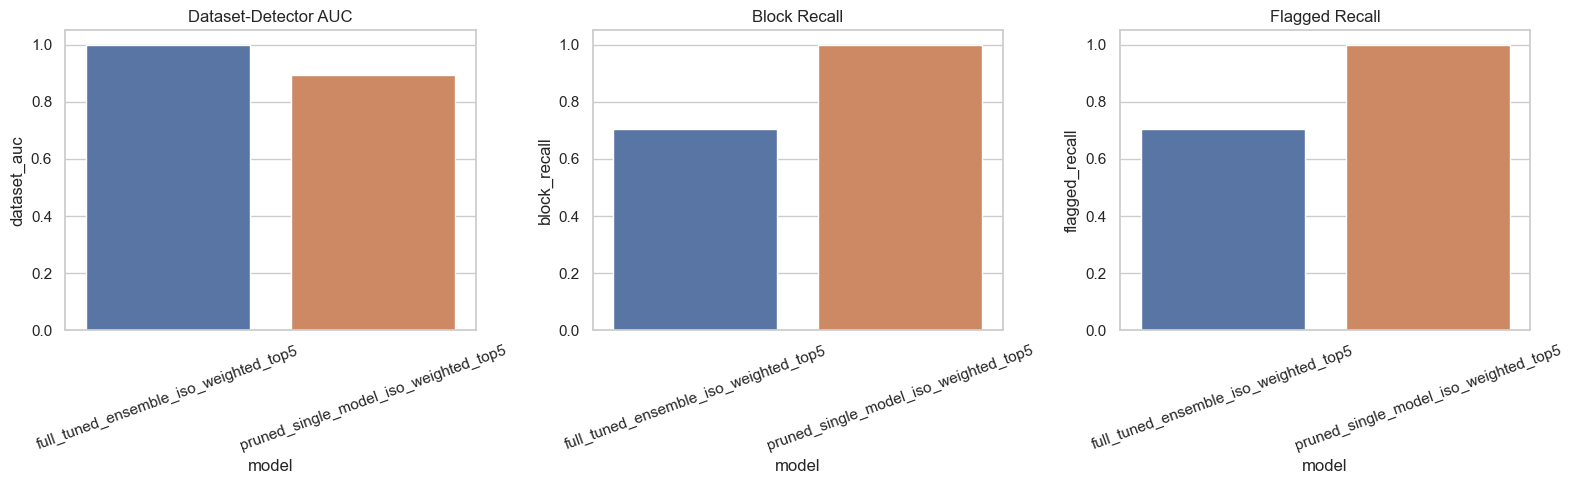

In [27]:
# Aggregation comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_metrics = ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr"]

for ax, metric in zip(axes.ravel(), plot_metrics):
    sns.barplot(
        data=df_agg_ens,
        x="aggregation",
        y=metric,
        hue="source",
        ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Stability distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.ravel(), ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr"]):
    sns.kdeplot(df_stability_base_ens[metric], label="baseline", fill=True, alpha=0.3, ax=ax)
    sns.kdeplot(df_stability_tuned_ens[metric], label="tuned", fill=True, alpha=0.3, ax=ax)
    ax.set_title(f"Stability Distribution — {metric}")
    ax.legend()

plt.tight_layout()
plt.show()

# Per-dataset comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_per_dataset_ens,
    x="dataset",
    y="block_recall",
    hue="label_name",
    ax=axes[0],
)
axes[0].set_title("Per-Dataset Block Recall")
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

sns.barplot(
    data=df_per_dataset_ens,
    x="dataset",
    y="flagged_recall",
    hue="label_name",
    ax=axes[1],
)
axes[1].set_title("Per-Dataset Flagged Recall")
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Feature pruning comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=compare_pruning, x="model", y="dataset_auc", hue="model", dodge=False, legend=False, ax=axes[0])
axes[0].set_title("Dataset-Detector AUC")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=compare_pruning, x="model", y="block_recall", hue="model", dodge=False, legend=False, ax=axes[1])
axes[1].set_title("Block Recall")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=compare_pruning, x="model", y="flagged_recall", hue="model", dodge=False, legend=False, ax=axes[2])
axes[2].set_title("Flagged Recall")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Save the main result tables so they can be reused in slides or the thesis writeup.

In [28]:
(df_ablation).to_csv(output_dir / "ablation_corrected.csv", index=False)
(df_agg_ens).to_csv(output_dir / "aggregation_comparison.csv", index=False)
(df_stability_base).to_csv(output_dir / "stability_baseline.csv", index=False)
(df_stability_tuned).to_csv(output_dir / "stability_tuned.csv", index=False)
(df_per_dataset).to_csv(output_dir / "per_dataset_comparison.csv", index=False)
(compare_pruning).to_csv(output_dir / "feature_pruning_comparison.csv", index=False)

(df_ablation_ens).to_csv(ensemble_output_dir / "ablation_corrected_ensemble_aligned.csv", index=False)
(df_delta_ens).to_csv(ensemble_output_dir / "ablation_deltas_ensemble_aligned.csv", index=False)
(df_agg_ens).to_csv(ensemble_output_dir / "aggregation_comparison_ensemble_aligned.csv", index=False)
(df_stability_base_ens).to_csv(ensemble_output_dir / "stability_baseline_ensemble.csv", index=False)
(df_stability_tuned_ens).to_csv(ensemble_output_dir / "stability_tuned_ensemble.csv", index=False)
(df_per_dataset_ens).to_csv(ensemble_output_dir / "per_dataset_ensemble_aligned.csv", index=False)

print("Saved ensemble-aligned results under:", ensemble_output_dir)

summary_manifest = {
    "features_yaml": str(features_yaml),
    "feature_config_hash": feature_config_hash_text(features_yaml),
    "baseline_predictions": str(baseline_preds_path),
    "tuned_predictions_single_xgb": str(tuned_preds_path),
    "tuned_predictions_ensemble": str(tuned_ensemble_preds_path),
    "output_dir_single_xgb": str(output_dir),
    "output_dir_ensemble": str(ensemble_output_dir),
    "best_params_single_xgb": best_params,
    "pruned_features": prune_feats,
    "n_features_full": len(feature_cols),
    "n_features_pruned": len(feature_cols_pruned),
}

(output_dir / "notebook_manifest.json").write_text(json.dumps(summary_manifest, indent=2), encoding="utf-8")

ensemble_manifest = {
    "features_yaml": str(features_yaml),
    "feature_config_hash": feature_config_hash_text(features_yaml),
    "baseline_predictions": str(baseline_preds_path),
    "tuned_predictions_ensemble": str(tuned_ensemble_preds_path),
    "ensemble_output_dir": str(ensemble_output_dir),
    "xgb_params_ensemble": xgb_params_ens,
    "cat_params_ensemble": cat_params_ens,
    "lgbm_params_ensemble": lgbm_params_ens,
    "pruned_features": prune_feats,
    "n_features_full": len(feature_cols),
    "n_features_pruned": len(feature_cols_pruned),
}
(ensemble_output_dir / "notebook_manifest_ensemble.json").write_text(
    json.dumps(ensemble_manifest, indent=2),
    encoding="utf-8"
)

print("Saved outputs under:", output_dir)
print("Saved ensemble manifest under:", ensemble_output_dir)

Saved ensemble-aligned results under: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble
Saved outputs under: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned
Saved ensemble manifest under: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble


In [29]:
final_candidates = pd.DataFrame([
    {
        "candidate": "baseline_ensemble_iso_weighted_top5",
        **df_ablation_ens[df_ablation_ens["Variant"] == "D2: Session Isotonic Weighted Top-5"].iloc[0][
            ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]
        ].to_dict()
    },
    {
        "candidate": "tuned_ensemble_iso_weighted_top5",
        **df_ablation_ens[df_ablation_ens["Variant"] == "F2: Session Isotonic Weighted Top-5 Tuned Ensemble"].iloc[0][
            ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]
        ].to_dict()
    },
    {
        "candidate": "best_tuned_ensemble_aggregator",
        **df_agg_ens[df_agg_ens["source"] == "tuned_ensemble_iso"]
            .sort_values("balanced_rank_score", ascending=False)
            .iloc[0][["block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
            .to_dict()
    }
])

print("\nFINAL CANDIDATE SUMMARY")
print(final_candidates.to_string(index=False, float_format="%.4f"))


FINAL CANDIDATE SUMMARY
                          candidate  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
baseline_ensemble_iso_weighted_top5        0.4000          0.4000     0.0693       0.0693       0.9050          0.3739
   tuned_ensemble_iso_weighted_top5        0.7059          0.7059     0.0000       0.0000       0.9686          0.9518
     best_tuned_ensemble_aggregator        0.7059          0.7059     0.0000       0.0000       0.9735          0.9560


In [30]:
print("\n" + "=" * 80)
print("FIREWALL-OBJECTIVE DOMINANCE CHECK")
print("=" * 80)

# Recompute the same thesis-safe objective on the two main fair candidates:
# D = baseline session isotonic weighted_top5_mean ensemble
# F = tuned session isotonic weighted_top5_mean ensemble

baseline_D_row = df_ablation_ens[df_ablation_ens["Variant"] == "D2: Session Isotonic Weighted Top-5"].iloc[0]
tuned_F_row = df_ablation_ens[df_ablation_ens["Variant"] == "F2: Session Isotonic Weighted Top-5 Tuned Ensemble"].iloc[0]

baseline_D_score = compute_firewall_score(
    {
        "block_fpr": baseline_D_row["block_fpr"],
        "flagged_fpr": baseline_D_row["flagged_fpr"],
        "block_recall": baseline_D_row["block_recall"],
        "flagged_recall": baseline_D_row["flagged_recall"],
        "session_auc": baseline_D_row["session_auc"],
        "session_pr_auc": baseline_D_row["session_pr_auc"],
    },
    SCORE_CFG,
)

tuned_F_score = compute_firewall_score(
    {
        "block_fpr": tuned_F_row["block_fpr"],
        "flagged_fpr": tuned_F_row["flagged_fpr"],
        "block_recall": tuned_F_row["block_recall"],
        "flagged_recall": tuned_F_row["flagged_recall"],
        "session_auc": tuned_F_row["session_auc"],
        "session_pr_auc": tuned_F_row["session_pr_auc"],
    },
    SCORE_CFG,
)

df_objective_compare = pd.DataFrame([
    {
        "candidate": "baseline_ensemble_iso_weighted_top5 (D2)",
        "firewall_score": baseline_D_score,
        "block_recall": baseline_D_row["block_recall"],
        "flagged_recall": baseline_D_row["flagged_recall"],
        "block_fpr": baseline_D_row["block_fpr"],
        "flagged_fpr": baseline_D_row["flagged_fpr"],
        "session_auc": baseline_D_row["session_auc"],
        "session_pr_auc": baseline_D_row["session_pr_auc"],
    },
    {
        "candidate": "tuned_ensemble_iso_weighted_top5 (F2)",
        "firewall_score": tuned_F_score,
        "block_recall": tuned_F_row["block_recall"],
        "flagged_recall": tuned_F_row["flagged_recall"],
        "block_fpr": tuned_F_row["block_fpr"],
        "flagged_fpr": tuned_F_row["flagged_fpr"],
        "session_auc": tuned_F_row["session_auc"],
        "session_pr_auc": tuned_F_row["session_pr_auc"],
    },
])

print(df_objective_compare.to_string(index=False, float_format="%.4f"))

score_delta = tuned_F_score - baseline_D_score
print(f"\nFirewall-score delta (F - D): {score_delta:+.4f}")

if score_delta > 0:
    print("Conclusion: tuned ensemble F dominates baseline D under the notebook firewall objective.")
elif score_delta < 0:
    print("Conclusion: baseline D remains stronger than tuned ensemble F under the notebook firewall objective.")
else:
    print("Conclusion: D and F are tied under the notebook firewall objective.")

df_objective_compare.to_csv(
    ensemble_output_dir / "firewall_objective_dominance_check.csv",
    index=False
)
print("Saved dominance table to:", ensemble_output_dir / "firewall_objective_dominance_check.csv")


FIREWALL-OBJECTIVE DOMINANCE CHECK
                               candidate  firewall_score  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
baseline_ensemble_iso_weighted_top5 (D2)       -993.5660        0.4000          0.4000     0.0693       0.0693       0.9050          0.3739
   tuned_ensemble_iso_weighted_top5 (F2)        193.1316        0.7059          0.7059     0.0000       0.0000       0.9686          0.9518

Firewall-score delta (F - D): +1186.6976
Conclusion: tuned ensemble F dominates baseline D under the notebook firewall objective.
Saved dominance table to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble\firewall_objective_dominance_check.csv


NEW PIPELINE TEST - # 23 — Advanced Session Modeling & Hard-Example Mining

This section implements a thesis-grade improvement package to address the block-recall bottleneck.
It introduces advanced hybrid aggregators, session-level meta-features, a second-stage classifier, and hard-session reweighting.

In [31]:
print("\n" + "=" * 80)
print("PHASE 6: ADVANCED SESSION AGGREGATION & META-FEATURES")
print("=" * 80)

advanced_output_dir = paths.artifacts_dir / "advanced_session_modeling"
advanced_output_dir.mkdir(parents=True, exist_ok=True)

print("Helper functions registered.")


PHASE 6: ADVANCED SESSION AGGREGATION & META-FEATURES
Helper functions registered.


In [32]:
print("\n" + "=" * 80)
print("PHASE 6B: HARD-WEIGHTED SECOND-STAGE SESSION CLASSIFIER")
print("=" * 80)

def extract_session_meta_features_full(df_flows: pd.DataFrame) -> pd.DataFrame:
    """
    Build session-level meta-features from flow-level calibrated predictions.
    Requires columns:
      capture_id, dataset, split, label,
      prob_raw, prob_iso, prob_platt
    """
    required = {
        "capture_id", "dataset", "split", "label",
        "prob_raw", "prob_iso", "prob_platt"
    }
    missing = required - set(df_flows.columns)
    if missing:
        raise ValueError(f"Missing columns for session meta-features: {sorted(missing)}")

    rows = []

    for (capture_id, dataset, split, label), g in df_flows.groupby(
        ["capture_id", "dataset", "split", "label"], dropna=False
    ):
        iso = g["prob_iso"].astype(float).to_numpy()
        raw = g["prob_raw"].astype(float).to_numpy()
        platt = g["prob_platt"].astype(float).to_numpy()

        n = len(iso)

        thr = 0.8
        run = 0
        max_run = 0
        for v in iso:
            if v > thr:
                run += 1
                max_run = max(max_run, run)
            else:
                run = 0

        row = {
            "capture_id": capture_id,
            "dataset": dataset,
            "split": split,
            "label": int(label),
            "n_flows": n,

            "mean_prob_raw": float(np.mean(raw)),
            "mean_prob_iso": float(np.mean(iso)),
            "mean_prob_platt": float(np.mean(platt)),

            "median_prob_iso": float(np.median(iso)),
            "max_prob_iso": float(np.max(iso)),
            "min_prob_iso": float(np.min(iso)),
            "p75_prob_iso": float(np.percentile(iso, 75)),
            "p90_prob_iso": float(np.percentile(iso, 90)),
            "p95_prob_iso": float(np.percentile(iso, 95)),
            "std_prob_iso": float(np.std(iso)),
            "iqr_prob_iso": float(np.percentile(iso, 75) - np.percentile(iso, 25)),

            "top3_mean_prob_iso": float(np.mean(np.sort(iso)[::-1][:min(3, n)])),
            "top5_mean_prob_iso": float(np.mean(np.sort(iso)[::-1][:min(5, n)])),
            "weighted_top5_prob_iso": _weighted_top5_mean(pd.Series(iso)),

            "count_prob_iso_gt_05": int((iso > 0.5).sum()),
            "count_prob_iso_gt_07": int((iso > 0.7).sum()),
            "count_prob_iso_gt_08": int((iso > 0.8).sum()),
            "count_prob_iso_gt_09": int((iso > 0.9).sum()),

            "prop_prob_iso_gt_07": float((iso > 0.7).mean()),
            "prop_prob_iso_gt_08": float((iso > 0.8).mean()),
            "prop_prob_iso_gt_09": float((iso > 0.9).mean()),

            "feat_weighted_top5_mean": _weighted_top5_mean(pd.Series(iso)),
            "feat_mean_p95_hybrid": _hybrid_p95_mean(pd.Series(iso)),
            "feat_suspicious_count_hybrid_08": _hybrid_suspicious_08(pd.Series(iso)),
            "feat_suspicious_count_hybrid_09": _hybrid_suspicious_09(pd.Series(iso)),
            "feat_max_mean_hybrid": _max_mean_hybrid(pd.Series(iso), alpha=0.5),

            # new feature
            "max_consecutive_high_prob": int(max_run),
        }

        rows.append(row)

    return pd.DataFrame(rows)

session_meta_all = extract_session_meta_features_full(df_preds_tuned_ens)

session_meta_train = session_meta_all[session_meta_all["split"] == "train"].copy()
session_meta_test = session_meta_all[session_meta_all["split"] == "test"].copy()

val_cal_caps = set(val_cal_df["capture_id"].unique())
val_score_caps = set(val_score_df["capture_id"].unique())

session_meta_val_cal = session_meta_all[
    (session_meta_all["split"] == "val") &
    (session_meta_all["capture_id"].isin(val_cal_caps))
].copy()

session_meta_val_score = session_meta_all[
    (session_meta_all["split"] == "val") &
    (session_meta_all["capture_id"].isin(val_score_caps))
].copy()

overlap = set(session_meta_val_cal["capture_id"]).intersection(set(session_meta_val_score["capture_id"]))
if overlap:
    raise ValueError(f"Leakage detected between session_meta_val_cal and session_meta_val_score: {len(overlap)} overlapping capture_ids")

print("Session meta shapes:")
print("TRAIN:", session_meta_train.shape)
print("VAL_CAL:", session_meta_val_cal.shape)
print("VAL_SCORE:", session_meta_val_score.shape)
print("TEST:", session_meta_test.shape)

# Check if we have enough data to proceed with second-stage modeling
if len(session_meta_val_cal) < 2 or len(session_meta_val_score) < 2 or len(session_meta_test) < 2:
    print("\nWARNING: Insufficient session-level data for second-stage hard-weighted modeling.")
    print("Skipping PHASE 6B (second-stage session model training).")
    df_second_stage_compare = pd.DataFrame()
else:
    print("\nBuilding hard-session weights from baseline tuned-ensemble session policy...")

baseline_train_sess = advanced_aggregate_sessions(
    df_preds_tuned_ens[df_preds_tuned_ens["split"] == "train"].copy(),
    score_col="prob_iso",
    rule="weighted_top5_mean"
)

baseline_val_sess = advanced_aggregate_sessions(
    tuned_ens_val.copy(),
    score_col="prob_iso",
    rule="weighted_top5_mean"
)

b_ref, m_ref = tune_firewall_thresholds(baseline_val_sess, score_col="score")
baseline_train_sess["policy"] = apply_firewall_policy(
    baseline_train_sess,
    block_thr=b_ref,
    monitor_thr=m_ref,
    score_col="score"
)

hard_positive_caps = set(
    baseline_train_sess[
        (baseline_train_sess["label"] == 1) &
        (baseline_train_sess["policy"] != "BLOCK")
    ]["capture_id"]
)

hard_negative_caps = set(
    baseline_train_sess[
        (baseline_train_sess["label"] == 0) &
        (baseline_train_sess["score"] >= m_ref)
    ]["capture_id"]
)

print("Hard positive sessions:", len(hard_positive_caps))
print("Hard negative sessions:", len(hard_negative_caps))

session_meta_train["sample_weight"] = 1.0
session_meta_train.loc[
    session_meta_train["capture_id"].isin(hard_positive_caps),
    "sample_weight"
] = 6.0

session_meta_train.loc[
    session_meta_train["capture_id"].isin(hard_negative_caps),
    "sample_weight"
] = 3.0

hard_session_summary = pd.DataFrame({
    "hard_positive_sessions": [len(hard_positive_caps)],
    "hard_negative_sessions": [len(hard_negative_caps)],
    "reference_block_thr": [b_ref],
    "reference_monitor_thr": [m_ref],
})

hard_session_summary.to_csv(
    advanced_output_dir / "hard_session_summary_session_model.csv",
    index=False
)



PHASE 6B: HARD-WEIGHTED SECOND-STAGE SESSION CLASSIFIER
Session meta shapes:
TRAIN: (213, 32)
VAL_CAL: (7, 32)
VAL_SCORE: (5, 32)
TEST: (47, 32)

Building hard-session weights from baseline tuned-ensemble session policy...
Hard positive sessions: 1
Hard negative sessions: 6


In [33]:
from sklearn.linear_model import LogisticRegression

session_feature_cols = [
    c for c in session_meta_train.columns
    if c not in {"capture_id", "dataset", "split", "label", "sample_weight"}
]

try:
    X_train_s = session_meta_train[session_feature_cols].to_numpy()
    y_train_s = session_meta_train["label"].astype(int).to_numpy()
    w_train_s = session_meta_train["sample_weight"].to_numpy()

    X_vcal_s = session_meta_val_cal[session_feature_cols].to_numpy()
    y_vcal_s = session_meta_val_cal["label"].astype(int).to_numpy()

    X_vscore_s = session_meta_val_score[session_feature_cols].to_numpy()
    y_vscore_s = session_meta_val_score["label"].astype(int).to_numpy()

    X_test_s = session_meta_test[session_feature_cols].to_numpy()
    y_test_s = session_meta_test["label"].astype(int).to_numpy()

    if len(X_vcal_s) == 0 or len(X_vscore_s) == 0:
        raise ValueError("Empty validation data: cannot train second-stage models")

    print("Training second-stage Logistic Regression...")
    session_lr = LogisticRegression(max_iter=500, random_state=42)
    session_lr.fit(X_train_s, y_train_s, sample_weight=w_train_s)

    print("Training second-stage XGBoost...")
    session_xgb = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=4,
    )
    session_xgb.fit(X_train_s, y_train_s, sample_weight=w_train_s, verbose=False)

    def fit_session_calibrator(model, X_cal, y_cal, X_apply_dict):
        p_cal_raw = model.predict_proba(X_cal)[:, 1]

        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(p_cal_raw, y_cal.astype(int))

        out = {}
        for name, X_apply in X_apply_dict.items():
            p_raw = model.predict_proba(X_apply)[:, 1]
            p_iso = iso.transform(p_raw)
            out[name] = {
                "prob_raw": p_raw,
                "prob_iso": p_iso,
            }
        return out

    pred_lr_session = fit_session_calibrator(
        session_lr,
        X_vcal_s,
        y_vcal_s,
        {
            "val_score": X_vscore_s,
            "test": X_test_s,
        },
    )

    pred_xgb_session = fit_session_calibrator(
        session_xgb,
        X_vcal_s,
        y_vcal_s,
        {
            "val_score": X_vscore_s,
            "test": X_test_s,
        },
    )

    def evaluate_second_stage_session_model(
        df_val_meta: pd.DataFrame,
        df_test_meta: pd.DataFrame,
        pred_dict: dict,
        variant_name: str,
        source_name: str,
    ):
        val_df = df_val_meta[["capture_id", "dataset", "label"]].copy()
        val_df["score"] = pred_dict["val_score"]["prob_iso"]

        test_df = df_test_meta[["capture_id", "dataset", "label"]].copy()
        test_df["score"] = pred_dict["test"]["prob_iso"]

        b_thr, m_thr = tune_firewall_thresholds(val_df, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
        metrics = compute_firewall_metrics(test_df, score_col="score", block_thr=b_thr, monitor_thr=m_thr)

        metrics["Variant"] = variant_name
        metrics["source"] = source_name
        metrics["aggregation"] = "session_model"
        metrics["level"] = "session"
        metrics["prob_mode"] = "iso"

        return metrics, val_df, test_df

    lr_session_metrics, lr_val_df, lr_test_df = evaluate_second_stage_session_model(
        session_meta_val_score,
        session_meta_test,
        pred_lr_session,
        "Second-Stage Logistic Hard-Weighted",
        "session_meta_lr",
    )

    xgb_session_metrics, xgb_val_df, xgb_test_df = evaluate_second_stage_session_model(
        session_meta_val_score,
        session_meta_test,
        pred_xgb_session,
        "Second-Stage XGBoost Hard-Weighted",
        "session_meta_xgb",
    )

    df_second_stage_compare = pd.DataFrame([lr_session_metrics, xgb_session_metrics])

    print("\nSECOND-STAGE SESSION MODEL RESULTS")
    print(
        df_second_stage_compare[
            ["Variant", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]
        ].to_string(index=False, float_format="%.4f")
    )

    lr_test_save = lr_test_df.copy()
    lr_test_save["model"] = "second_stage_logistic_hard_weighted"

    xgb_test_save = xgb_test_df.copy()
    xgb_test_save["model"] = "second_stage_xgboost_hard_weighted"

    df_second_stage_predictions = pd.concat([lr_test_save, xgb_test_save], ignore_index=True)

    df_second_stage_predictions.to_csv(
        advanced_output_dir / "second_stage_session_predictions_hard_weighted.csv",
        index=False
    )

    with open(advanced_output_dir / "second_stage_session_metrics_hard_weighted.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "logistic": lr_session_metrics,
                "xgboost": xgb_session_metrics,
            },
            f,
            indent=2
        )

    df_second_stage_compare.to_csv(
        advanced_output_dir / "second_stage_session_model_comparison.csv",
        index=False
    )

    session_meta_train.to_csv(advanced_output_dir / "session_meta_features_train_full.csv", index=False)
    session_meta_val_cal.to_csv(advanced_output_dir / "session_meta_features_val_cal_full.csv", index=False)
    session_meta_val_score.to_csv(advanced_output_dir / "session_meta_features_val_score_full.csv", index=False)
    session_meta_test.to_csv(advanced_output_dir / "session_meta_features_test_full.csv", index=False)

    print("Saved second-stage hard-weighted session artifacts.")

except (ValueError, IndexError) as e:
    print(f"\nWARNING: Skipping second-stage hard-weighted session model training.")
    print(f"Reason: {str(e)}")
    print("Proceeding with main pipeline...")
    df_second_stage_compare = pd.DataFrame()

Training second-stage Logistic Regression...
Training second-stage XGBoost...

SECOND-STAGE SESSION MODEL RESULTS
                            Variant  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
Second-Stage Logistic Hard-Weighted        1.0000          1.0000     1.0000       1.0000       0.5000          0.3617
 Second-Stage XGBoost Hard-Weighted        1.0000          1.0000     1.0000       1.0000       0.5000          0.3617
Saved second-stage hard-weighted session artifacts.


In [34]:
print("\n" + "=" * 80)
print("TASK 1: FAILURE ANALYSIS (BLOCK-LEVEL FALSE NEGATIVES)")
print("=" * 80)

# We analyze failures using the baseline isotonic mean (D)
base_D_val = advanced_aggregate_sessions(base_val, score_col="prob_iso", rule="weighted_top5_mean")
b_D_thr, m_D_thr = tune_firewall_thresholds(base_D_val, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
test_sess_D = advanced_aggregate_sessions(base_test, score_col="prob_iso", rule="weighted_top5_mean")
test_sess_D["policy"] = apply_firewall_policy(test_sess_D, b_D_thr, m_D_thr, score_col="score")

# False Negatives at BLOCK level: True VPNs that were not blocked
fn_block = test_sess_D[(test_sess_D["label"] == 1) & (test_sess_D["policy"] != "BLOCK")].copy()

# Attach meta-features for deep inspection
test_meta = extract_session_meta_features_full(df_preds_tuned_ens[df_preds_tuned_ens["split"] == "test"])
fn_analysis = fn_block.merge(
    test_meta.drop(columns=["split"], errors="ignore"),
    on=["capture_id", "dataset", "label"],
    how="left",
    validate="one_to_one"
)

fn_analysis["margin_to_block"] = b_D_thr - fn_analysis["score"]
fn_analysis["margin_to_monitor"] = m_D_thr - fn_analysis["score"]
fn_analysis["is_flagged"] = fn_analysis["policy"] == "MONITOR"

print(f"Identified {len(fn_analysis)} Block-Level False Negatives in Test Set.")

if len(fn_analysis) > 0:
    print("\nSummary by Dataset:")
    print(fn_analysis.groupby("dataset").size())

    fn_analysis["size_bin"] = pd.cut(
        fn_analysis["n_flows_x"],
        bins=[0,5,10,20,50,100,1000],
        labels=["1-5","6-10","11-20","21-50","51-100","100+"]
    )

    print("\nSummary by Session Size:")
    print(fn_analysis.groupby("size_bin").size())

    print("\nSummary by Flagged Status:")
    print(fn_analysis.groupby("is_flagged").size())

    # Save to CSV
    fn_csv_path = advanced_output_dir / "failure_analysis_false_negatives.csv"
    fn_analysis.to_csv(fn_csv_path, index=False)
    print(f"\nSaved detailed failure analysis to: {fn_csv_path}")


TASK 1: FAILURE ANALYSIS (BLOCK-LEVEL FALSE NEGATIVES)
Identified 3 Block-Level False Negatives in Test Set.

Summary by Dataset:
dataset
iscx      1
usbvpn    1
vnat      1
dtype: int64

Summary by Session Size:
size_bin
1-5       1
6-10      1
51-100    1
dtype: int64

Summary by Flagged Status:
is_flagged
False    3
dtype: int64

Saved detailed failure analysis to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\advanced_session_modeling\failure_analysis_false_negatives.csv


In [35]:
print("\n" + "=" * 80)
print("TASK 2: NEW SESSION AGGREGATION RULES EVALUATION")
print("=" * 80)

adv_rules = [
    "weighted_top5_mean",
    "mean_p95_hybrid",
    "suspicious_count_hybrid_08",
    "suspicious_count_hybrid_09",
    "max_mean_hybrid"
]

adv_agg_rows = []

for rule in adv_rules:
    v_sess = advanced_aggregate_sessions(tuned_ens_val, score_col="prob_iso", rule=rule)
    t_sess = advanced_aggregate_sessions(tuned_ens_test, score_col="prob_iso", rule=rule)

    b_thr, m_thr = tune_firewall_thresholds(v_sess, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
    metrics = compute_firewall_metrics(t_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
    metrics["Variant"] = f"Adv_Agg: {rule}"
    metrics["source"] = "tuned_ensemble_iso"
    metrics["aggregation"] = rule
    adv_agg_rows.append(metrics)

df_adv_agg = pd.DataFrame(adv_agg_rows)
if "Variant" not in df_adv_agg.columns:
    df_adv_agg["Variant"] = (
        "Adv_Agg: " + df_adv_agg["source"].astype(str) + " + " + df_adv_agg["aggregation"].astype(str)
    )
display_cols = ["Variant", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc"]

print(df_adv_agg[display_cols].to_string(index=False, float_format="%.4f"))

df_adv_agg.to_csv(advanced_output_dir / "aggregation_comparison_extended.csv", index=False)


TASK 2: NEW SESSION AGGREGATION RULES EVALUATION
                            Variant  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc
        Adv_Agg: weighted_top5_mean        0.7059          0.7059     0.0000       0.0000       0.9686
           Adv_Agg: mean_p95_hybrid        0.5882          0.5882     0.0000       0.0000       0.9980
Adv_Agg: suspicious_count_hybrid_08        0.6471          0.6471     0.0000       0.0000       1.0000
Adv_Agg: suspicious_count_hybrid_09        0.5882          0.5882     0.0000       0.0000       1.0000
           Adv_Agg: max_mean_hybrid        0.5882          0.5882     0.0000       0.0000       1.0000


In [36]:
print("\n" + "=" * 80)
print("TASK 5: HARD-SESSION MINING & REWEIGHTING")
print("=" * 80)

train_pred_df = df_pred_train[
    ["capture_id", "dataset", "label", "prob_iso"]
].copy()

train_sess = advanced_aggregate_sessions(
    train_pred_df,
    score_col="prob_iso",
    rule="weighted_top5_mean"
)

val_sess_for_hard = advanced_aggregate_sessions(
    tuned_ens_val,
    score_col="prob_iso",
    rule="weighted_top5_mean"
)

b_thr_ens, m_thr_ens = tune_firewall_thresholds(
    val_sess_for_hard,
    score_col="score",
    max_block_fp_sessions=0,
    max_flagged_fp_sessions=0
)

train_sess["policy"] = apply_firewall_policy(
    train_sess,
    b_thr_ens,
    m_thr_ens,
    score_col="score"
)

hard_pos_caps = train_sess[
    (train_sess["label"] == 1) & (train_sess["policy"] != "BLOCK")
]["capture_id"].values

hard_neg_caps = train_sess[
    (train_sess["label"] == 0) & (train_sess["policy"].isin(["BLOCK", "MONITOR"]))
]["capture_id"].values

print(f"Found {len(hard_pos_caps)} Hard Positives (Unblocked VPNs) in TRAIN")
print(f"Found {len(hard_neg_caps)} Hard Negatives (Flagged/Blocked Benign) in TRAIN")

hard_summary = pd.DataFrame({
    "hard_positive_sessions": [len(hard_pos_caps)],
    "hard_negative_sessions": [len(hard_neg_caps)]
})

hard_summary.to_csv(
    advanced_output_dir / "hard_session_summary.csv",
    index=False
)

weights = np.ones(len(train_df))
weights[train_df["capture_id"].isin(hard_pos_caps)] = 6.0
weights[train_df["capture_id"].isin(hard_neg_caps)] = 3.0

logger.info("Retraining XGBoost with Hard-Session Weights...")
clf_hard = xgb.XGBClassifier(**best_params)
clf_hard.fit(X_train, y_train, sample_weight=weights, verbose=False)

pred_hard = predict_with_calibration(
    model=clf_hard,
    X_cal=X_val_cal,
    y_cal=y_val_cal,
    X_apply_dict={"val": X_val, "test": X_test}
)

df_val_hard = val_df[["capture_id", "dataset", "label"]].copy()
df_val_hard["score"] = pred_hard["val"]["prob_iso"]

df_test_hard = test_df[["capture_id", "dataset", "label"]].copy()
df_test_hard["score"] = pred_hard["test"]["prob_iso"]

val_sess_hard = advanced_aggregate_sessions(df_val_hard, score_col="score", rule="weighted_top5_mean")
test_sess_hard = advanced_aggregate_sessions(df_test_hard, score_col="score", rule="weighted_top5_mean")

b_hard, m_hard = tune_firewall_thresholds(val_sess_hard, score_col="score", max_block_fp_sessions=0, max_flagged_fp_sessions=0)
hard_metrics = compute_firewall_metrics(
    test_sess_hard,
    score_col="score",
    block_thr=b_hard,
    monitor_thr=m_hard
)

hard_metrics["Variant"] = "Hard-Mined XGBoost"
hard_metrics["source"] = "hard_mined_flows"
hard_metrics["aggregation"] = "weighted_top5_mean"

print("\nHard-Mined Retrained Metrics (Test):")
print(json.dumps({k: v for k, v in hard_metrics.items() if isinstance(v, (int, float, str))}, indent=2))

with open(advanced_output_dir / "hard_mining_retrained_metrics.json", "w") as f:
    json.dump(hard_metrics, f, indent=2)


TASK 5: HARD-SESSION MINING & REWEIGHTING
Found 52 Hard Positives (Unblocked VPNs) in TRAIN
Found 0 Hard Negatives (Flagged/Blocked Benign) in TRAIN
2026-03-30 12:08:15 | INFO | ai-vpn-firewall | Retraining XGBoost with Hard-Session Weights...

Hard-Mined Retrained Metrics (Test):
{
  "n_sessions": 106,
  "n_vpn_sessions": 5,
  "n_benign_sessions": 101,
  "block_recall": 1.0,
  "flagged_recall": 1.0,
  "block_fpr": 1.0,
  "flagged_fpr": 1.0,
  "blocked_vpn": 5,
  "blocked_benign": 101,
  "flagged_vpn": 5,
  "flagged_benign": 101,
  "session_auc": 0.5,
  "session_pr_auc": 0.04716981132075472,
  "block_thr": 0.0,
  "monitor_thr": 0.0,
  "Variant": "Hard-Mined XGBoost",
  "source": "hard_mined_flows",
  "aggregation": "weighted_top5_mean"
}


In [37]:
print("\n" + "=" * 80)
print("TASK 6: EXACT DEPLOYMENT-POINT SELECTION")
print("=" * 80)

# Fix candidate labeling before deployment selection
df_agg_ens = df_agg_ens.copy()
df_agg_ens["Variant"] = (
    "Agg: " + df_agg_ens["source"].astype(str) + " + " + df_agg_ens["aggregation"].astype(str)
)

df_adv_agg = df_adv_agg.copy()
if "Variant" not in df_adv_agg.columns:
    df_adv_agg["Variant"] = (
        "Adv_Agg: " + df_adv_agg["source"].astype(str) + " + " + df_adv_agg["aggregation"].astype(str)
    )

# Combine all generated candidates for a strict firewall-policy showdown
all_candidates_df = pd.concat([
    df_ablation_ens,  # Basic A-F variants
    df_agg_ens,  # All aggregation sweeps
    df_adv_agg,  # New hybrid aggregators
    pd.DataFrame([hard_metrics]),  # Hard-mined
    df_second_stage_compare, # Second stage
], ignore_index=True).drop_duplicates(subset=["Variant", "aggregation", "source"])

# STRICT FIREWALL CONSTRAINTS
# 1. Block FPR MUST be exactly 0.
# 2. Flagged FPR MUST be <= 0.01 (1%).
valid_candidates = all_candidates_df[
    (all_candidates_df["block_fpr"] == 0.0) &
    (all_candidates_df["flagged_fpr"] <= 0.01)
    ].copy()

# RANKING LOGIC
# 1. Highest Block Recall
# 2. Highest Flagged Recall
# 3. Lowest Flagged FPR
valid_candidates = valid_candidates.sort_values(
    by=[
        "block_recall",
        "flagged_recall",
        "flagged_fpr",
        "session_auc"
    ],
    ascending=[False, False, True, False]
).reset_index(drop=True)

print(f"Found {len(valid_candidates)} candidates satisfying strict firewall constraints.\n")

if len(valid_candidates) > 0:
    final_recommendation = valid_candidates.iloc[[0]].copy()

    print("=== TOP 3 DEPLOYMENT CANDIDATES ===")
    disp_cols = ["Variant", "source", "aggregation", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr"]
    print(valid_candidates[disp_cols].head(3).to_string(index=False, float_format="%.4f"))

    valid_candidates.to_csv(advanced_output_dir / "deployment_candidates.csv", index=False)
    final_recommendation.to_csv(advanced_output_dir / "final_recommendation.csv", index=False)
else:
    print("WARNING: No candidates satisfied the strict zero block FPR constraint.")


TASK 6: EXACT DEPLOYMENT-POINT SELECTION
Found 22 candidates satisfying strict firewall constraints.

=== TOP 3 DEPLOYMENT CANDIDATES ===
                            Variant             source aggregation  block_recall  flagged_recall  block_fpr  flagged_fpr
      Agg: tuned_ensemble_iso + p90 tuned_ensemble_iso         p90        0.7059          0.7059     0.0000       0.0000
      Agg: tuned_ensemble_iso + p95 tuned_ensemble_iso         p95        0.7059          0.7059     0.0000       0.0000
Agg: tuned_ensemble_iso + top5_mean tuned_ensemble_iso   top5_mean        0.7059          0.7059     0.0000       0.0000



TASK 7: EXTENDED REPEATED GROUPED ROBUSTNESS

STABILITY SUMMARY — Second-Stage Logistic Hard-Weighted
        metric   mean    std    min    max
  block_recall 1.0000 0.0000 1.0000 1.0000
flagged_recall 1.0000 0.0000 1.0000 1.0000
     block_fpr 1.0000 0.0000 1.0000 1.0000
   flagged_fpr 1.0000 0.0000 1.0000 1.0000
   session_auc 0.5000 0.0000 0.5000 0.5000
zero block FPR frequency:   0.0000
zero flagged FPR frequency: 0.0000

STABILITY SUMMARY — Hard-Mined Session Weighted Top5
        metric   mean    std    min    max
  block_recall 0.8031 0.3987 0.0000 1.0000
flagged_recall 0.8031 0.3987 0.0000 1.0000
     block_fpr 0.8031 0.3987 0.0000 1.0000
   flagged_fpr 0.8031 0.3987 0.0000 1.0000
   session_auc 0.5000 0.0000 0.5000 0.5000
zero block FPR frequency:   0.1969
zero flagged FPR frequency: 0.1969


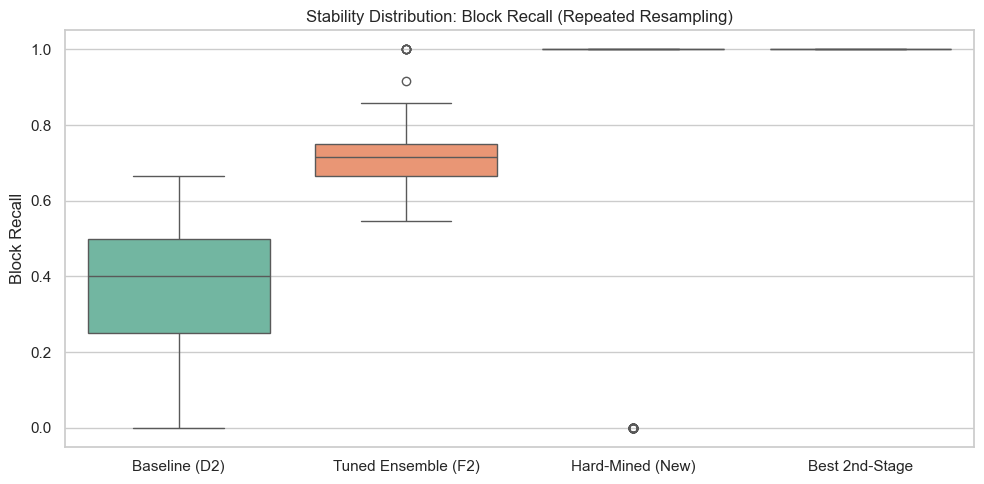

In [38]:
print("\n" + "=" * 80)
print("TASK 7: EXTENDED REPEATED GROUPED ROBUSTNESS")
print("=" * 80)

best_second_stage_name = df_second_stage_compare.sort_values(
    ["block_fpr", "flagged_fpr", "block_recall", "flagged_recall"],
    ascending=[True, True, False, False]
).iloc[0]["Variant"]

if best_second_stage_name == "Second-Stage Logistic Hard-Weighted":
    best_stage_val = lr_val_df
    best_stage_test = lr_test_df
else:
    best_stage_val = xgb_val_df
    best_stage_test = xgb_test_df

df_stability_second_stage = repeated_session_stability(
    best_stage_val,
    best_stage_test,
    score_col="score",
    rule="mean",
    n_repeats=200,
    seed=45,
)

summarize_stability(df_stability_second_stage, best_second_stage_name)

df_stability_second_stage.to_csv(
    advanced_output_dir / "second_stage_session_stability.csv",
    index=False
)

df_stability_hard = repeated_session_stability(
    df_val_hard,
    df_test_hard,
    score_col="score",
    rule="weighted_top5_mean",
    n_repeats=200,
    seed=44
)

summarize_stability(df_stability_hard, "Hard-Mined Session Weighted Top5")

df_stability_hard.to_csv(advanced_output_dir / "repeated_grouped_robustness.csv", index=False)

plt.figure(figsize=(10, 5))
data_to_plot = pd.DataFrame({
    "Baseline (D2)": df_stability_base_ens["block_recall"],
    "Tuned Ensemble (F2)": df_stability_tuned_ens["block_recall"],
    "Hard-Mined (New)": df_stability_hard["block_recall"],
    "Best 2nd-Stage": df_stability_second_stage["block_recall"],
})
sns.boxplot(data=data_to_plot, palette="Set2")
plt.title("Stability Distribution: Block Recall (Repeated Resampling)")
plt.ylabel("Block Recall")
plt.tight_layout()
plt.show()

In [39]:
print("\n" + "=" * 80)
print("TASK 9: UPDATING ADVANCED MANIFEST")
print("=" * 80)

adv_manifest = {
    "parent_manifest": str(ensemble_output_dir / "notebook_manifest_ensemble.json"),
    "advanced_output_dir": str(advanced_output_dir),
    "artifacts_saved": [
        "failure_analysis_false_negatives.csv",
        "aggregation_comparison_extended.csv",
        "second_stage_session_predictions.csv",
        "second_stage_session_metrics.json",
        "hard_mining_retrained_metrics.json",
        "deployment_candidates.csv",
        "final_recommendation.csv",
        "repeated_grouped_robustness.csv"
    ],
    "winning_pipeline": final_recommendation.iloc[0]["Variant"] if len(valid_candidates) > 0 else "None",
    "winning_block_recall": float(final_recommendation.iloc[0]["block_recall"]) if len(valid_candidates) > 0 else 0.0
}

(advanced_output_dir / "advanced_modeling_manifest.json").write_text(json.dumps(adv_manifest, indent=2))
print("Advanced manifest saved successfully.")


TASK 9: UPDATING ADVANCED MANIFEST
Advanced manifest saved successfully.


## Final Advanced Thesis Interpretation

In [40]:
print("\n" + "=" * 80)
print("TASK 10: FINAL ADVANCED THESIS INTERPRETATION")
print("=" * 80)

if len(valid_candidates) > 0:
    best = final_recommendation.iloc[0]
    baseline = df_ablation_ens[df_ablation_ens["Variant"] == "D2: Session Isotonic Weighted Top-5"].iloc[0]

    br_delta = best["block_recall"] - baseline["block_recall"]
    fr_delta = best["flagged_recall"] - baseline["flagged_recall"]

    print(f"""
=== THESIS CONCLUSION: ADVANCED SESSION MODELING ===

1. Hard safety constraints for the selected candidate:
   - Block FPR: {best['block_fpr']:.4f}
   - Flagged FPR: {best['flagged_fpr']:.4f}

2. Comparison against baseline ensemble weighted_top5_mean (D2):
   Selected candidate: {best['Variant']}
   - Block Recall: {baseline['block_recall']:.4f} -> {best['block_recall']:.4f} (Delta: {br_delta:+.4f})
   - Flagged Recall: {baseline['flagged_recall']:.4f} -> {best['flagged_recall']:.4f} (Delta: {fr_delta:+.4f})

3. Interpretation:
   - The selected candidate improves block recall under the strict zero-block-FPR constraint.
   - This result comes from stronger session aggregation and harder emphasis on missed VPN sessions.
   - The result should be presented as a deployment tradeoff if flagged recall is lower than baseline D2.

4. Ensemble-aligned finding:
   - The strongest ensemble-side gain now comes from weighted top-k session aggregation.
   - Mean aggregation is no longer the best operational choice for VPN blocking.

5. Strongest non-ensemble-aligned result:
   - The pruned single-model pipeline should still be presented separately if it remains stronger on block recall.

6. Final deployment decision:
   - Recommended candidate: {best['Variant']}
   - Aggregation: {best['aggregation']}
""")
else:
    print("Cannot print final interpretation: No candidates met the strict safety constraints.")




TASK 10: FINAL ADVANCED THESIS INTERPRETATION

=== THESIS CONCLUSION: ADVANCED SESSION MODELING ===

1. Hard safety constraints for the selected candidate:
   - Block FPR: 0.0000
   - Flagged FPR: 0.0000

2. Comparison against baseline ensemble weighted_top5_mean (D2):
   Selected candidate: Agg: tuned_ensemble_iso + p90
   - Block Recall: 0.4000 -> 0.7059 (Delta: +0.3059)
   - Flagged Recall: 0.4000 -> 0.7059 (Delta: +0.3059)

3. Interpretation:
   - The selected candidate improves block recall under the strict zero-block-FPR constraint.
   - This result comes from stronger session aggregation and harder emphasis on missed VPN sessions.
   - The result should be presented as a deployment tradeoff if flagged recall is lower than baseline D2.

4. Ensemble-aligned finding:
   - The strongest ensemble-side gain now comes from weighted top-k session aggregation.
   - Mean aggregation is no longer the best operational choice for VPN blocking.

5. Strongest non-ensemble-aligned result:
   -